<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK4_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 4 — VIF, AIC and BIC on Logistic Regression, and Risk Scoring Systems**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering  
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

## Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB1 | Data loading, cleaning, column removal, binary re-encoding, export |
| NB2 | Exploratory Data Analysis (distributions, clustering, feature screening) |
| NB3 | Outlier detection and clinical plausibility audit |
| **NB4 (this notebook)** | VIF multicollinearity control, AIC variable selection, unsupervised clustering with selected variables, clinical risk scoring system |

## Pipeline overview

| Stage | Section | Description |
|-------|---------|-------------|
| 1 | Libraries | Package imports |
| 2 | Configuration | Global parameters, feature sets, variable typing |
| 3 | VIF | Multicollinearity control via Variance Inflation Factor |
| 4 | AIC/BIC | Backward stepwise logistic regression (statsmodels) |
| 5 | Coefficients | β, odds ratios, p-values, forest plot |
| 6 | K-Means | Descriptive clustering (elbow + silhouette) |
| 7 | FAMD + Ward | Hierarchical clustering for mixed-type data |
| 8 | LOESS | Cutpoint identification via nonparametric smoothing |
| 9 | Binning | Variable discretisation and reference category selection |
| 10 | Scoring | Ridge logistic regression + β-rounding (Zhang et al. 2017) |
| 11 | Validation | AUC-ROC, calibration, clinical metrics |
| 12 | Scorecard | Integer point table for clinical use |
| 13 | Confusion matrix | Youden-optimal threshold |
| 14 | Conclusions | Findings, limitations, and next steps |

---

## Objetives

In **Notebook 4 (NB4)** there are two principal tasks:

- Select variables based on the **Variance Inflation Factor (VIF)**, the **Akaike Information Criteria (AIC)** and the **Bayesian Information Criteria (BIC)**.
- Built three different risk score systems based on Logistic Regresion and employing the selected variables.  

## Multi-outcome support

This notebook is designed to run for **any of the three mortality endpoints** by changing `TARGET_COL` in the configuration cell (Section 2). The risk scoring system, validation metrics, and clustering analyses will automatically adapt.

## **1. Libraries**

| Library | Role |
|---------|------|
| `pandas`, `numpy` | Data handling |
| `sklearn` | Imputation, scaling, logistic regression, clustering, OHE, metrics |
| `statsmodels` | Unpenalised Logit for AIC/BIC stepwise and coefficient tables |
| `scipy` | Savitzky-Golay filter (LOESS), statistical tests, hierarchical clustering |
| `prince` | FAMD for mixed-type dimensionality reduction |
| `matplotlib`, `seaborn` | Visualisation |

In [ ]:
import os
!pip install -q prince

from __future__ import annotations
import numpy as np
import pandas as pd
from typing import Dict, List, Optional, Sequence, Tuple

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    ConfusionMatrixDisplay,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from scipy.signal import savgol_filter
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy import stats

import prince
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, Markdown

plt.rcParams["font.size"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Libraries loaded.")

✅ Libraries loaded.


### Global plot style

All figures in this notebook use the **TFG unified style**, a `theme_bw()`-equivalent
for matplotlib/seaborn, consistent across **NB2, NB3, and NB4**. Inspired by **Zhang Z et al. (2017)** *Development of scoring system for risk stratification in clinical medicine*.

**Key visual conventions:**
- White background, light grey grid, thin black panel border.
- Serif font family (DejaVu Serif / Times New Roman).
- Consistent colour palette via `TFG_COLORS` (alias: `TFG_COLORS` for backward compatibility).
- Output: 100 dpi screen / 150 dpi saved.

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ── TFG Unified Plot Style (Zhang et al. 2017 – theme_bw equivalent) ─────────
TFG_STYLE = {
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "axes.edgecolor":    "black",
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#d9d9d9",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "-",
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "Times New Roman", "serif"],
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   9,
    "legend.frameon":    True,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  4,
    "ytick.major.size":  4,
    "figure.dpi":        100,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
}
mpl.rcParams.update(TFG_STYLE)
sns.set_theme(style="white", rc=TFG_STYLE)

# ── TFG Colour Palette ────────────────────────────────────────────────────────
TFG_COLORS = {
    "loess_curve":       "#3366CC",
    "loess_band":        "#B0C4DE",
    "cutpoint":          "#2ca02c",
    "ref_line":          "#d62728",
    "survivors":         "#FFD700",
    "non_survivors":     "#87CEEB",
    "dead_leaf":         "#d62728",
    "alive_leaf":        "#4CAF50",
    "pred_prob_line":    "black",
    "pred_prob_ci":      "#d62728",
    "ideal_line":        "#888888",
    "calib_curve":       "black",
    "jitter_pts":        "#555555",
    "inliers":           "#aec6cf",
    "cluster_0":         "#5b9bd5",
    "cluster_1":         "#ed7d31",
    "cluster_2":         "#70ad47",
    "cluster_consensus": "#404040",
}

import os

def _save_fig(fig, fname: str, dpi: int = 150) -> None:
    """Save a figure to OUTPUT_DIR and display it inline.

    Parameters
    ----------
    fig   : matplotlib Figure
        The figure object to save.
    fname : str
        Output filename (e.g. ``"fig_03_vif.png"``).
    dpi   : int, optional
        Output resolution in dots per inch (default 150).

    Notes
    -----
    ``OUTPUT_DIR`` must be defined in §2 before this function is called.
    If Drive is not mounted the figure is displayed but the save is skipped.
    """
    try:
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=dpi, bbox_inches="tight")
    except Exception as _e:
        print(f"\u26a0 Could not save {fname}: {_e}")
    plt.show()
    plt.close(fig)


## **2. Shared configuration**

Everything below is designed for changing parameters:
- switch outcome (`TARGET_COL`)
- change the feature set used in the score
- tweak LOESS cutpoint behaviour / plot style

**Key idea:** the LOESS **section 8.** produces *diagnostics + cutpoints*.  The binning **section 9.** then applies cutpoints with this priority:

1) `CLINICAL_CUTS_PER_OUTCOME[TARGET_COL]` (primary)  
2) LOESS-suggested cut-points (fallback)

---

### Parameters

| Parameter | Purpose |
|---|---|
| `TARGET_COL` | Outcome endpoint (`"Mort. 2D"`, `"Mort. 7D"`, `"Mort. 30D"`) |
| `FEATURES_PER_OUTCOME` | Variables retained after VIF + AIC/BIC (per outcome) |
| `BINARY_VARS`, `GCS_VARS`, `CATEGORICAL_VARS` | Variable typing (drives preprocessing + binning) |
| `CATEGORICAL_MAPS` | Integer-code → clinical-group mapping for categorical variables (e.g. Ritmo) |
| `LOESS_PARAMS` + `MONO` | Cutpoint detection and monotonic constraints |
| `PLOT_CFG` | Plot readability (sizes, jitter, densities) |


> **Note on variable pre-selection:** The feature sets in `FEATURES_PER_OUTCOME`
> were fixed following an initial exploratory run (not reproduced here).
> VIF and AIC/BIC in **sections 3–4** validate and refine this pre-selection; they do not
> replace it. If the dataset changes substantially, these lists should be
> revisited from the full 30-variable prehospital set.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2  SHARED CONFIGURATION (single edit point)
# ══════════════════════════════════════════════════════════════════════════════

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)

# ── Outcome & split ───────────────────────────────────────────────────────────
TARGET_COL    = "Mort. 30D"          # ← Change: "Mort. 2D" | "Mort. 7D" | "Mort. 30D"
ALL_MORT_COLS = ["Mort. 2D", "Mort. 7D", "Mort. 30D"]
TEST_SIZE     = 0.25

# ── Per-outcome feature sets ──────────────────────────────────────────────────
FEATURES_PER_OUTCOME = {
    "Mort. 2D":  ["Edad", "GCS", "Lactato", "TT", "FR", "SpO2", "O2"],
    "Mort. 7D":  ["Edad", "GCS", "Lactato", "SpO2", "O2", "TT", "Resrv."],
    "Mort. 30D": ["Edad", "GCS", "Lactato", "SpO2", "Resrv.", "O2"],
}
FEATURES = FEATURES_PER_OUTCOME[TARGET_COL]  # active set — do not edit directly

# ── Variable typing ────────────────────────────────────────────────────────────
BINARY_VARS = {"O2", "VNI", "VAD", "Resrv.", "IOT", "Venturi", "Nebul.", "Gafas", "O2 sup."}
GCS_VARS    = {"GCS"}

# ── Polychotomous categorical variables ───────────────────────────────────────
# Ritmo and ST are non-binary categorical variables with clinically distinct classes.
# Both are dummy-expanded for VIF and AIC/BIC (§§3–4).
# Add either variable to FEATURES_PER_OUTCOME to include it in the scoring pipeline.
# Note: ST and Ritmo are unlikely to survive backward selection.
CATEGORICAL_VARS = {"Ritmo", "ST"}

CATEGORICAL_MAPS: Dict[str, Dict[int, str]] = {
    "Ritmo": {
        1:  "Sinusal",
        2:  "Arritmia sinusal",
        3:  "Fibrilación auricular",
        4:  "Flutter auricular",
        5:  "Taquicardia",
        6:  "Taquicardia supraventricular",
        7:  "Taquicardia ventricular",
        8:  "Bradicardia",
        9:  "Bloqueo AV 1º",
        10: "Bloqueo AV 2º tipo I",
        11: "Bloqueo AV 2º tipo II",
        12: "Bloqueo AV completo",
        13: "Ritmo de marcapasos",
        14: "Ritmo de la unión",
        15: "Ritmo idioventricular",
        16: "Bloqueo de rama derecha",
        17: "Bloqueo de rama izquierda",
        18: "Extrasístoles ventriculares",
        19: "Asistolia",
        20: "Fibrilación ventricular",
        21: "Otros",
    },
    "ST": {
        1: "NO",
        2: "Elevación",
        3: "Descenso",
        4: "T. picudas",
        5: "T. negativas",
        6: "Onda Q",
        7: "Otros",
    },
}

# Reference-first display order for each categorical variable.
# Ritmo: "Sinusal" is the natural physiological reference.
# ST:    "Normal"  is the natural clinical reference.
CATEGORICAL_GROUP_ORDER: Dict[str, List[str]] = {
    "Ritmo": [
        "Sinusal",
        "Arritmia sinusal",
        "Fibrilación auricular",
        "Flutter auricular",
        "Taquicardia",
        "Taquicardia supraventricular",
        "Taquicardia ventricular",
        "Bradicardia",
        "Bloqueo AV 1º",
        "Bloqueo AV 2º tipo I",
        "Bloqueo AV 2º tipo II",
        "Bloqueo AV completo",
        "Ritmo de marcapasos",
        "Ritmo de la unión",
        "Ritmo idioventricular",
        "Bloqueo de rama derecha",
        "Bloqueo de rama izquierda",
        "Extrasístoles ventriculares",
        "Asistolia",
        "Fibrilación ventricular",
        "Otros",
    ],
    "ST": [
        "NO",
        "Elevación",
        "Descenso",
        "T. picaduras",
        "T. negativas"
        "Onda Q",
        "Otros",
    ],
}

# ── LOESS tuning parameters (per continuous variable) ────────────────────────
LOESS_PARAMS: Dict[str, Dict] = {
    "Edad":     dict(n_bins=80, min_bin_n=25, frac=0.14, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.010),
    "Lactato":  dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.015),
    "SpO2":     dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=3,  min_risk_delta=0.012),
    "TT":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=5,  min_risk_delta=0.012),
    "FR":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "Glucemia": dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAM":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAS":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "TAD":      dict(n_bins=70, min_bin_n=25, frac=0.16, max_cuts=3,
                     trim_percentile=5,  min_risk_delta=0.012),
    "FC":       dict(n_bins=80, min_bin_n=25, frac=0.16, max_cuts=2,
                     trim_percentile=5,  min_risk_delta=0.012),
}

# ── Monotonic constraints (applied post-LOWESS) ───────────────────────────────
MONO: Dict[str, Optional[str]] = {
    "Edad":     "increasing",
    "Lactato":  "increasing",
    "SpO2":     None,
    "TT":       None,
    "FR":       None,
    "Glucemia": None,
    "TAM":      None,
    "TAS":      None,
    "TAD":      None,
    "FC":       None,
}

# ── pd.cut convention per continuous variable ─────────────────────────────────
RIGHT_TRUE_VARS  = {"Edad", "Lactato", "FR", "Glucemia", "TAM", "TAS", "TAD"}
RIGHT_FALSE_VARS = {"SpO2", "TT", "FC"}

# ── Clinical cutpoints per outcome ────────────────────────────────────────────
CLINICAL_CUTS_PER_OUTCOME: Dict[str, Dict[str, List[float]]] = {
    "Mort. 2D": {
        "Edad":    [55.0, 70.0, 85.0],
        "Lactato": [3.5, 6.0],
        "TT":      [35.5, 37.5],
        "FR":      [14, 22, 28],
        "SpO2":    [90.0, 94.0],
    },
    "Mort. 7D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],
        "FR":      [14, 22, 28],
    },
    "Mort. 30D": {
        "Edad":    [58.0, 72.0, 85.0],
        "Lactato": [3.5, 6.0],
        "FR":      [14.0, 22.0, 28.0],
        "SpO2":    [90.0, 94.0],
        "TT":      [35.5, 37.5],
        "FC":      [60, 100, 120],
    },
}

# ── Plot config ───────────────────────────────────────────────────────────────
PLOT_CFG = dict(
    figsize=(13.5, 7.5),
    show_scatter=True,
    scatter_jitter=0.06,
    scatter_alpha=0.12,
    scatter_size=10,
    event_size=18,
    hist_bins=40,
    show_density_panel=True,
    max_points_scatter=4000,
)
# ── Output directory (NB4 figures and tables) ───────────────────────────────
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS"



### Data loading and master train/test split

The dataset (`dataset_FINAL.csv`) is loaded from the `/content/` folder. A **single train/test split** is created here and reused throughout all sections.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `TEST_SIZE` | 0.25 | 75 % / 25 % split; test set held out for final validation |
| `RANDOM_STATE` | 42 | Fixed seed guarantees full reproducibility across runs |
| Stratification | None | Not stratified on `TARGET_COL`: stratifying would yield a different `df_train` each time the outcome changes, making 3 VIF outcome-dependent |

> **Design principle:** all model fitting (VIF **3.**, AIC/BIC **4.**, Ridge **10.**) uses
> `df_train` exclusively. LOESS plots (**section 8**) use the full `df` for visual density
> estimation, but cut-points are fixed manually in `CLINICAL_CUTS_PER_OUTCOME`.
> Reference category selection (**section 9.**) also uses `df_train` to prevent data leakage.


In [ ]:
# ── Data path (Colab) ─────────────────────────────────────────────────────────
CLEAN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/TFG/dataset_FINAL.csv"

try:
    from google.colab import drive
    from pathlib import Path
    if not Path("/content/drive").exists():
        drive.mount("/content/drive")
except Exception:
    pass

print(f"Target outcome : {TARGET_COL}")
print(f"Active features: {FEATURES}")
print(f"  Continuous (LOESS): {[v for v in FEATURES if v not in (BINARY_VARS | GCS_VARS | CATEGORICAL_VARS)]}")
print(f"  GCS (clinical bins): {[v for v in FEATURES if v in GCS_VARS]}")
print(f"  Categorical (mapped): {[v for v in FEATURES if v in CATEGORICAL_VARS]}")
print(f"  Binary             : {[v for v in FEATURES if v in BINARY_VARS]}")

df = pd.read_csv(CLEAN_DATA_PATH)
df.columns = df.columns.astype(str).str.strip()

print(f"\nDataset: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))

# ── Drop stale _cat columns from any prior run ───────────────────────────────
stale = [c for c in df.columns if c.endswith("_cat")]
if stale:
    df.drop(columns=stale, inplace=True)

# ── Master train/test split (single source of truth) ─────────────────────────
# All model fitting (VIF 3, AIC/BIC 4, Ridge 10) uses df_train exclusively.
# LOESS plots (8) use the full df for visual density but cuts are fixed manually.
# Reference category selection (9) uses df_train to avoid leakage.

# Split is not stratified on any outcome: stratifying on TARGET_COL would
# produce a different df_train each time TARGET_COL changes, making §3 VIF
# outcome-dependent. A fixed random_state guarantees full reproducibility.
df_train, df_test = train_test_split(
    df.copy(), test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
print(f"\nMaster split — Train: {len(df_train)} | Test: {len(df_test)}")
for col in ALL_MORT_COLS:
    if col in df_train.columns:
        n_ev = int((pd.to_numeric(df_train[col], errors="coerce") == 1).sum())
        pct  = n_ev / len(df_train) * 100
        print(f"  {col}: {n_ev} events ({pct:.2f}%)")
# ── Create output directory (figures + tables for NB4) ──────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")



Target outcome : Mort. 30D
Active features: ['Edad', 'GCS', 'Lactato', 'SpO2', 'Resrv.', 'O2']
  Continuous (LOESS): ['Edad', 'Lactato', 'SpO2']
  GCS (clinical bins): ['GCS']
  Categorical (mapped): []
  Binary             : ['Resrv.', 'O2']

Dataset: 2376 rows × 33 columns


,Edad,Sexo,FR,SpO2,O2,TAS,TAD,TAM,FC,TT,...,Nebul.,VNI,IOT,VAD,VM,MAVA,TTE,Mort. 2D,Mort. 7D,Mort. 30D
0,87,1,23,76,1,82,49,60.000000,88,34.9,...,0,0,0,0,0,0,0,1,1,1
1,87,0,34,85,1,233,126,161.666667,105,36.7,...,1,0,0,0,0,0,0,0,0,0
2,88,1,6,50,1,193,106,135.000000,117,38.2,...,1,0,0,0,0,0,0,0,0,0



Master split — Train: 1782 | Test: 594
  Mort. 2D: 89 events (4.99%)
  Mort. 7D: 130 events (7.30%)
  Mort. 30D: 201 events (11.28%)
Output directory: /content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS


### Design matrix construction for VIF and AIC/BIC

`get_design_matrix()` converts the active feature list into a fully numeric design matrix
for VIF computation (§3) and backward stepwise selection (§4).

**Processing rules:**
- **Scalar features** (continuous, binary, ordinal) — cast to `float` as-is.
- **Nominal polychotomous** (`Ritmo`, `ST`) — expanded to *(C − 1)* dummy columns
  (`drop_first=True`; reference = lowest integer code).
- **Atomic token blocking** — all dummies for one nominal variable enter or leave
  backward selection together, preventing partial-elimination artefacts.

| Output | Type | Description |
|--------|------|-------------|
| `X` | `pd.DataFrame` | Fully numeric design matrix |
| `token_to_cols` | `dict[str, list[str]]` | Maps each original feature to its column(s) in `X` |


In [ ]:
# ── Nominal polychotomous variables (dummy-expanded for VIF and AIC/BIC) ──────
# Derived from CATEGORICAL_VARS (currently: Ritmo, ST).
# Each variable is expanded to (C-1) dummy columns with drop_first=True.
NOMINAL_POLYCHOT_VARS: List[str] = sorted(CATEGORICAL_VARS)


def get_design_matrix(
    df: pd.DataFrame,
    features: List[str],
    nominal_vars: Optional[List[str]] = None,
    drop_first: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, List[str]]]:
    """Build a fully numeric design matrix for VIF and AIC/BIC stepwise.

    Nominal polychotomous variables (Ritmo, ST) are expanded to (C-1) dummy
    columns (drop_first=True; reference = lowest integer code).
    All other features are cast to float as-is.

    Returns
    -------
    X : pd.DataFrame
        Numeric design matrix (rows × predictors).
    token_to_cols : dict[str, list[str]]
        Maps each original feature token to its column(s) in X.
        Nominal vars map to (C-1) dummy names; scalar vars to [feature].
    """
    if nominal_vars is None:
        nominal_vars = NOMINAL_POLYCHOT_VARS

    non_nominal = [f for f in features if f not in nominal_vars]
    X = df[non_nominal].copy().astype(float)
    token_to_cols: Dict[str, List[str]] = {f: [f] for f in non_nominal}

    for var in nominal_vars:
        if var not in features:
            continue
        unique_vals = sorted(df[var].dropna().unique())
        cat_dtype   = pd.CategoricalDtype(categories=unique_vals, ordered=False)
        dummies = pd.get_dummies(
            df[var].astype(cat_dtype),
            prefix=var, drop_first=drop_first, dtype=float,
        )
        X = pd.concat([X, dummies], axis=1)
        token_to_cols[var] = list(dummies.columns)

    return X, token_to_cols


## **3. Variance Inflation Factor (VIF) — multicollinearity control**

VIF measures how well each predictor can be explained by the remaining predictors:

| VIF | Interpretation |
|-----|----------------|
| ≈ 1 | No collinearity |
| > 5 | Moderate concern |
| > 10 | Strong collinearity — consider removal |
| ∞ | Perfect collinearity (e.g., GCS = GCS.O + GCS.V + GCS.M) |

A threshold of 5 is applied for stricter control. Moderate collinearity inflates standard errors meaningfully and destabilises coefficient estimates used for β-rounding downstream.

### Iterative removal strategy

The function `iterative_vif_removal()` implements an automated protocol:

1. Compute VIF for all numeric predictors (after median imputation + z-score scaling).
2. If the maximum VIF exceeds `vif_threshold`, remove the variable with the highest VIF (unless it is in the `protected` set).
3. Repeat until all VIF ≤ threshold or only protected variables remain.

### Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `df_train` | `pd.DataFrame` | — | Training split only (no leakage) |
| `target_cols` | `List[str]` | — | Outcome columns to exclude from X |
| `vif_threshold` | `float` | `5.0` | Maximum acceptable VIF |
| `protected` | `List[str]` | `[]` | Variables never removed regardless of VIF |

### Removal history (this dataset)

The iterative process typically removes:
- **GCS subcomponents** (GCS.O, GCS.V, GCS.M) — perfect collinearity with total GCS
- **TAS, TAD** — collinear with TAM (retain TAM as the composite)
- **FiO2, O2 sup.** — collinear with other respiratory variables
- **MAVA** — collinear with VM/IOT
- **VM** — collinear with IOT (retained IOT as more interpretable)

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `vif_final` | `pd.DataFrame` | Final VIF table after iterative removal |
| `removed_vars` | `List[str]` | Variables removed in order |
| `retained_vars` | `List[str]` | Final variable set |

In [ ]:
def compute_vif_table(X_scaled: np.ndarray, col_names: List[str]) -> pd.DataFrame:
    """Compute the Variance Inflation Factor (VIF) for every column.

    Parameters
    ----------
    X_scaled  : np.ndarray, shape (n_samples, n_features)
        Standardised design matrix (mean-centred, unit variance, no missing values).
    col_names : List[str]
        Feature names aligned with the columns of ``X_scaled``.

    Returns
    -------
    pd.DataFrame
        Columns [``"Variable"``, ``"VIF"``], sorted descending by VIF.

    Notes
    -----
    VIF_j = 1 / (1 − R2_j), where R2_j is the R-squared obtained by regressing
    column j on all other columns. VIF > 5 = moderate; VIF > 10 = strong collinearity.
    """
    vif = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
    return (pd.DataFrame({"Variable": col_names, "VIF": vif})
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))


def iterative_vif_removal(
    df_train: pd.DataFrame,
    target_cols: List[str],
    vif_threshold: float = 5.0,
    protected: Optional[List[str]] = None,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    """Iteratively remove the highest-VIF variable until all VIF <= threshold.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training data (features + targets). Categorical variables must already
        be excluded before calling this function (VIF is undefined for nominals).
    target_cols : List[str]
        Columns to exclude from X.
    vif_threshold : float
        Maximum acceptable VIF.
    protected : List[str] or None
        Variables that cannot be removed regardless of VIF.
    verbose : bool
        Print removal log.

    Returns
    -------
    Tuple[pd.DataFrame, List[str], List[str]]
        (final_vif_table, removed_variables, retained_variables)
    """
    protected = set(protected or [])

    X = df_train.drop(columns=[c for c in target_cols if c in df_train.columns], errors="ignore")
    X = X.select_dtypes(include=np.number)

    # Remove constant columns
    var = X.var(numeric_only=True)
    X = X[var[var > 0].index.tolist()]

    removed = []
    step = 0

    while True:
        X_imp = SimpleImputer(strategy="median").fit_transform(X)
        X_sc  = StandardScaler().fit_transform(X_imp)
        vif_df = compute_vif_table(X_sc, list(X.columns))

        max_vif = vif_df["VIF"].max()
        if max_vif <= vif_threshold:
            break

        candidates = vif_df[~vif_df["Variable"].isin(protected)]
        if candidates.empty or candidates["VIF"].max() <= vif_threshold:
            break

        worst = candidates.iloc[0]["Variable"]
        step += 1
        if verbose:
            print(f"  Step {step}: Remove {worst} (VIF = {candidates.iloc[0]['VIF']:.1f})")
        removed.append(worst)
        X = X.drop(columns=[worst])

    # Final VIF table
    X_imp = SimpleImputer(strategy="median").fit_transform(X)
    X_sc  = StandardScaler().fit_transform(X_imp)
    vif_final = compute_vif_table(X_sc, list(X.columns))

    return vif_final, removed, list(X.columns)


# ── Run iterative VIF removal ─────────────────────────────────────────────────
# VIF runs on all numeric columns of df_train.
# CATEGORICAL_VARS (e.g. Ritmo) are excluded: VIF requires a linear fit and
# is only meaningful for numeric predictors; integer-coded nominal variables
# would produce a single spurious coefficient.
# Outcome columns (ALL_MORT_COLS) are excluded as targets, not predictors.
# FEATURES_PER_OUTCOME is NOT consulted here — it is filled manually by the
# user after inspecting AIC/BIC results.

# ── Variables excluded before VIF (direct removal, no VIF computed) ──────────
# Add here any variables that should be dropped before the VIF loop runs,
# e.g. variables known a priori to be redundant, clinically inappropriate or
# proof from other runs that cause inestability to AIC/BIC.
# These are distinct from `protected` (which stays in but cannot be removed).
EXCLUDE_FROM_VIF: List[str] = ["Gafas", "VAD"]

df_vif = df_train.drop(
    columns=[
        c for c in list(CATEGORICAL_VARS) + EXCLUDE_FROM_VIF
        if c in df_train.columns
    ]
)

print(f"\nRemoved before from VIF ({len(EXCLUDE_FROM_VIF)}): {EXCLUDE_FROM_VIF}")

print("\n─── Iterative VIF removal ───")
vif_final, removed_vars, retained_vars = iterative_vif_removal(
    df_vif,
    target_cols=ALL_MORT_COLS,
    vif_threshold=2.0, #The threshold had to be adjusted lower than 5 to remove some of the redundant variables
    protected=["Edad", "GCS", "Lactato", "SpO2", "TT", "FR", "Glucemia", "TAM"],
    verbose=True,
)

print(f"\nRemoved ({len(removed_vars)}): {removed_vars}")
print(f"Retained ({len(retained_vars)}): {retained_vars}")
print("\nFinal VIF table:")
display(vif_final)


Removed before from VIF (2): ['Gafas', 'VAD']

─── Iterative VIF removal ───


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


  Step 1: Remove GCS.V (VIF = inf)
  Step 2: Remove TAD (VIF = 371.9)
  Step 3: Remove VM (VIF = 42.1)
  Step 4: Remove MAVA (VIF = 10.3)
  Step 5: Remove GCS.M (VIF = 9.6)
  Step 6: Remove TAS (VIF = 7.6)
  Step 7: Remove FiO2 (VIF = 6.3)
  Step 8: Remove GCS.O (VIF = 4.2)
  Step 9: Remove O2 sup. (VIF = 3.1)

Removed (9): ['GCS.V', 'TAD', 'VM', 'MAVA', 'GCS.M', 'TAS', 'FiO2', 'GCS.O', 'O2 sup.']
Retained (17): ['Edad', 'Sexo', 'FR', 'SpO2', 'O2', 'TAM', 'FC', 'TT', 'GCS', 'Lactato', 'Glucemia', 'Venturi', 'Resrv.', 'Nebul.', 'VNI', 'IOT', 'TTE']

Final VIF table:


,Variable,VIF
0,GCS,1.916364
1,SpO2,1.898580
2,O2,1.725507
3,IOT,1.624398
4,Nebul.,1.556204
5,Resrv.,1.443590
6,FR,1.410324
7,Lactato,1.253962
8,FC,1.242063
9,Venturi,1.221155


## **4. AIC/BIC backward stepwise selection**

Using `statsmodels.Logit`, backward elimination is performed on the VIF-reduced variable set:

1. Fit the full model with all retained variables.
2. For each variable (except protected ones), compute the IC (AIC or BIC) of the model without it.
3. Remove the variable whose removal yields the largest IC improvement.
4. Repeat until no removal improves the IC.

**AIC** (Akaike Information Criterion) favours predictive performance; **BIC** penalises complexity more strongly and favours parsimony.

### Functions

#### `fit_logit_sm(X_df, y)`

Fit a statsmodels Logit with robust index alignment (handles numpy/pandas mismatches).

#### `information_criteria(res)`

Compute explicitly:
- $AIC = −2·LL + 2k$
- $BIC = −2·LL + ln(n)·k$


#### `backward_stepwise_ic(X_df, y, criterion, protected, tol, max_steps)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `criterion` | `str` | `"AIC"` | `"AIC"` or `"BIC"` |
| `protected` | `List[str]` | `None` | Variables that cannot be removed |
| `tol` | `float` | `1e-6` | Minimum IC improvement to continue |
| `max_steps` | `int` | `200` | Maximum iterations |
| **Returns** | | | `(selected_cols, history_df, fitted_result)` |

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `selected_aic` | `List[str]` | Variables selected by AIC |
| `selected_bic` | `List[str]` | Variables selected by BIC |
| `hist_aic`, `hist_bic` | `pd.DataFrame` | Stepwise removal history |

In [ ]:
def fit_logit_sm(X_df: pd.DataFrame, y) -> sm.discrete.discrete_model.BinaryResultsWrapper:
    """Fit statsmodels Logit with robust convergence and index handling.

    Uses method='newton' as primary solver; falls back to 'bfgs' on failure.
    """
    Xc = sm.add_constant(X_df, has_constant="add")
    if isinstance(y, pd.DataFrame):
        y_obj = y.iloc[:, 0]
    else:
        y_obj = y
    if isinstance(y_obj, pd.Series):
        try:
            y_aligned = y_obj.loc[X_df.index]
        except Exception:
            y_aligned = pd.Series(np.asarray(y_obj).ravel(), index=X_df.index)
        y_vec = np.asarray(y_aligned).ravel()
    else:
        y_vec = np.asarray(y_obj).ravel()

    model = sm.Logit(y_vec, Xc)
    try:
        res = model.fit(method="newton", maxiter=200, disp=False)
    except Exception:
        res = model.fit(method="bfgs",   maxiter=400, disp=False)
    if not res.mle_retvals.get("converged", True):
        print(f"⚠ Logit did not converge — coefficients may be unreliable.")
    return res


def information_criteria(res):
    """Compute AIC and BIC explicitly.

    AIC = -2*LL + 2k
    BIC = -2*LL + ln(n)*k
    k counts the intercept + one parameter per column in the design matrix,
    so nominal variables expanded to (C-1) dummies contribute k += (C-1).
    """
    ll = float(res.llf)
    k  = int(len(res.params))
    n  = int(res.nobs)
    aic = -2 * ll + 2 * k
    bic = -2 * ll + np.log(n) * k
    return aic, bic, ll, k, n


def backward_stepwise_ic(
    X_full: pd.DataFrame,
    token_to_cols: Dict[str, List[str]],
    y: np.ndarray,
    criterion: str = "AIC",
    protected: Optional[List[str]] = None,
    tol: float = 1e-6,
    max_steps: int = 200,
) -> Tuple[List[str], pd.DataFrame, object]:
    """Backward elimination by AIC or BIC with token-level blocking.

    Nominal polychotomous variables (e.g. Ritmo, 21 categories -> 20 dummies)
    are treated as atomic blocks: all dummy columns enter or leave together.
    The information criterion counts k = intercept + one parameter per dummy
    column, correctly penalising the full complexity of each block.

    Parameters
    ----------
    X_full : pd.DataFrame
        Fully expanded design matrix from get_design_matrix().
    token_to_cols : dict[str, list[str]]
        Maps each original feature token to its column(s) in X_full.
    y : array-like
        Binary outcome.
    criterion : {'AIC', 'BIC'}
    protected : list of str, optional
        Tokens that cannot be removed.
    tol : float
        Minimum IC improvement to continue elimination.
    max_steps : int

    Returns
    -------
    selected_tokens : list of str
    history_df : pd.DataFrame
    fitted_result : statsmodels BinaryResultsWrapper
        Fitted on the final selected columns — used by §5 for coefficient table.
    """
    import warnings
    protected = set(protected or [])
    current_tokens = list(token_to_cols.keys())

    def _cols(tokens):
        return [col for tok in tokens for col in token_to_cols[tok]]

    res = fit_logit_sm(X_full[_cols(current_tokens)], y)
    aic, bic, ll, k, n = information_criteria(res)
    current_ic = aic if criterion.upper() == "AIC" else bic

    history = [{"Step": 0, "Removed": None, "IC": current_ic,
                "AIC": aic, "BIC": bic, "LogLik": ll, "k": k, "n": n}]

    for step in range(1, max_steps + 1):
        best_ic, best_token, best_res, best_stats = current_ic, None, None, None

        for token in current_tokens:
            if token in protected:
                continue
            trial_tokens = [t for t in current_tokens if t != token]
            trial_cols   = _cols(trial_tokens)
            if not trial_cols:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    tr = fit_logit_sm(X_full[trial_cols], y)
                a, b, l, kk, nn = information_criteria(tr)
                ic = a if criterion.upper() == "AIC" else b
            except Exception:
                continue
            if ic < best_ic - tol:
                best_ic, best_token, best_res = ic, token, tr
                best_stats = (a, b, l, kk, nn)

        if best_token is None:
            break
        current_tokens.remove(best_token)
        current_ic = best_ic
        a, b, l, kk, nn = best_stats
        history.append({"Step": step, "Removed": best_token, "IC": current_ic,
                        "AIC": a, "BIC": b, "LogLik": l, "k": kk, "n": nn})
        res = best_res
        print(f"  Step {step:2d}: Remove {best_token:<20s} | {criterion.upper()} = {current_ic:.4f} | k = {kk}")

    return current_tokens, pd.DataFrame(history), res


# ── Run AIC and BIC backward stepwise ────────────────────────────────────────
# Input: retained_vars from 3. VIF + CATEGORICAL_VARS (excluded from VIF by
# design). FEATURES_PER_OUTCOME is NOT consulted — it is filled manually
# by the user after inspecting these results.

stepwise_features = [
    v for v in retained_vars
    if v not in ALL_MORT_COLS and v in df_train.columns
] + [
    v for v in CATEGORICAL_VARS
    if v in df_train.columns
]

y_train_sm = df_train[TARGET_COL].astype(int)
X_full_sm, token_to_cols_sm = get_design_matrix(df_train, stepwise_features)

# Drop rows with any NaN in the design matrix (statsmodels requires complete cases)
_valid = X_full_sm.dropna().index.intersection(y_train_sm.dropna().index)
X_full_sm  = X_full_sm.loc[_valid]
y_train_sm = y_train_sm.loc[_valid]

print("=" * 60)
print(f"§4  Backward Stepwise — AIC  ({TARGET_COL})")
print("=" * 60)
selected_aic, hist_aic, sm_aic = backward_stepwise_ic(
    X_full_sm, token_to_cols_sm, y_train_sm,
    criterion="AIC",
)
print(f"\n  -> AIC selected tokens: {selected_aic}")

print("\n" + "=" * 60)
print(f"§4  Backward Stepwise — BIC  ({TARGET_COL})")
print("=" * 60)
selected_bic, hist_bic, sm_bic = backward_stepwise_ic(
    X_full_sm, token_to_cols_sm, y_train_sm,
    criterion="BIC",
)
print(f"\n  -> BIC selected tokens: {selected_bic}")

print("\n" + "=" * 60)
print("Stepwise history — AIC")
display(hist_aic)
print("\nStepwise history — BIC")
display(hist_bic)

§4  Backward Stepwise — AIC  (Mort. 30D)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
  Step  1: Remove Ritmo                | AIC = 965.0412 | k = 23
  Step  2: Remove ST                   | AIC = 960.8130 | k = 18
  Step  3: Remove Venturi              | AIC = 958.9383 | k = 17
  Step  4: Remove Nebul.               | AIC = 957.1402 | k = 16
  Step  5: Remove Sexo                 | AIC = 955.4410 | k = 15
  Step  6: Remove Glucemia             | AIC = 953.8476 | k = 14
  Step  7: Remove TT

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
⚠ Logit did not converge — coefficients may be unreliable.
  Step  1: Remove Ritmo                | BIC = 1091.2076 | k = 23
  Step  2: Remove ST                   | BIC = 1059.5518 | k = 18
  Step  3: Remove Venturi              | BIC = 1052.1917 | k = 17
  Step  4: Remove Nebul.               | BIC = 1044.9081 | k = 16
  Step  5: Remove Sexo                 | BIC = 1037.7234 | k = 15
  Step  6: Remove Glucemia             | BIC = 1030.6445 | k = 14
  Step  7: Rem

,Step,Removed,IC,AIC,BIC,LogLik,k,n
0,0,None,978.097516,978.097516,1197.517180,-449.048758,40,1782
1,1,Ritmo,965.041249,965.041249,1091.207556,-459.520625,23,1782
2,2,ST,960.812976,960.812976,1059.551825,-462.406488,18,1782
3,3,Venturi,958.938322,958.938322,1052.191679,-462.469161,17,1782
4,4,Nebul.,957.140232,957.140232,1044.908098,-462.570116,16,1782
5,5,Sexo,955.441024,955.441024,1037.723398,-462.720512,15,1782
6,6,Glucemia,953.847594,953.847594,1030.644477,-462.923797,14,1782
7,7,TTE,952.413191,952.413191,1023.724582,-463.206596,13,1782
8,8,TAM,951.294208,951.294208,1017.120108,-463.647104,12,1782
9,9,VNI,950.327875,950.327875,1010.668283,-464.163938,11,1782



Stepwise history — BIC


,Step,Removed,IC,AIC,BIC,LogLik,k,n
0,0,None,1197.517180,978.097516,1197.517180,-449.048758,40,1782
1,1,Ritmo,1091.207556,965.041249,1091.207556,-459.520625,23,1782
2,2,ST,1059.551825,960.812976,1059.551825,-462.406488,18,1782
3,3,Venturi,1052.191679,958.938322,1052.191679,-462.469161,17,1782
4,4,Nebul.,1044.908098,957.140232,1044.908098,-462.570116,16,1782
5,5,Sexo,1037.723398,955.441024,1037.723398,-462.720512,15,1782
6,6,Glucemia,1030.644477,953.847594,1030.644477,-462.923797,14,1782
7,7,TTE,1023.724582,952.413191,1023.724582,-463.206596,13,1782
8,8,TAM,1017.120108,951.294208,1017.120108,-463.647104,12,1782
9,9,VNI,1010.668283,950.327875,1010.668283,-464.163938,11,1782


### **Remaining variables after AIC and BIC selection**

The coefficient table below guides the final choice of variables for each outcome.
ST dummies (Elevación, Depresión, etc.) appear in this step if ST is included in
`FEATURES_PER_OUTCOME`; given their expected rarity in prehospital data they are
unlikely to survive backward elimination.

#### `MORT. 2D`
- AIC selected: Edad, GCS, Lactato, TT, FR, SpO2, O2
- BIC selected: [fill from final run]

#### `MORT. 7D`
- AIC selected: Edad, GCS, Lactato, SpO2, O2, TT, Resrv.
- BIC selected: [fill from final run]

#### `MORT. 30D`
- AIC selected: Edad, GCS, Lactato, SpO2, Resrv., O2
- BIC selected: [fill from final run]

## **5. Coefficient table — β, Odds Ratios, p-values**

The AIC-selected model coefficients are reported with 95 % confidence intervals and odds ratios to support clinical interpretability.

### Function: `coef_table_sm_full(res, alpha, drop_const)`

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `res` | statsmodels result | — | Fitted Logit result |
| `alpha` | `float` | `0.05` | Significance level for CIs |
| `drop_const` | `bool` | `False` | Whether to exclude the intercept row |
| **Returns** | `pd.DataFrame` | | Table with β, SE, p-value, CIs, OR, OR CIs |

In [ ]:
def coef_table_sm_full(res, alpha: float = 0.05, drop_const: bool = False) -> pd.DataFrame:
    """Extract β, SE, p-value, 95 % CI, OR and OR CI from a fitted Logit result.

    Parameters
    ----------
    res        : statsmodels BinaryResultsWrapper
        Fitted Logit model (output of :func:`fit_logit_sm`).
    alpha      : float, default 0.05
        Significance level for Wald CIs (two-tailed).
    drop_const : bool, default False
        If ``True``, the intercept row is excluded from the returned table.

    Returns
    -------
    pd.DataFrame
        Columns: variable, beta, se, p_value, CI_low, CI_high,
        OR, OR_CI_low, OR_CI_high. Sorted ascending by p-value.
    """
    conf = res.conf_int(alpha=alpha)
    conf.columns = ["CI_low", "CI_high"]
    out = pd.DataFrame({
        "variable": res.params.index,
        "beta":     res.params.values,
        "se":       res.bse.values,
        "p_value":  res.pvalues.values,
        "CI_low":   conf["CI_low"].values,
        "CI_high":  conf["CI_high"].values,
    })
    out["OR"]         = np.exp(out["beta"])
    out["OR_CI_low"]  = np.exp(out["CI_low"])
    out["OR_CI_high"] = np.exp(out["CI_high"])
    out = out.sort_values("p_value")
    if drop_const:
        out = out[out["variable"] != "const"]
    return out.reset_index(drop=True)


display(Markdown(f"### AIC model coefficients ({TARGET_COL})"))
display(coef_table_sm_full(sm_aic, drop_const=True))

### AIC model coefficients (Mort. 30D)

,variable,beta,se,p_value,CI_low,CI_high,OR,OR_CI_low,OR_CI_high
0,GCS,-0.197662,0.027279,4.297861e-13,-0.251129,-0.144195,0.820647,0.777922,0.865719
1,Edad,0.037254,0.006137,1.272721e-09,0.025227,0.049282,1.037957,1.025547,1.050516
2,Lactato,0.114827,0.031133,2.257539e-04,0.053808,0.175847,1.121680,1.055282,1.192255
3,O2,0.717960,0.204495,4.465942e-04,0.317158,1.118762,2.050246,1.373219,3.061063
4,SpO2,-0.029657,0.009223,1.302561e-03,-0.047735,-0.011580,0.970778,0.953387,0.988487
5,Resrv.,0.537507,0.258143,3.732384e-02,0.031555,1.043458,1.711734,1.032059,2.839017
6,TT,-0.159518,0.083649,5.652320e-02,-0.323467,0.004432,0.852555,0.723636,1.004442
7,FR,0.018534,0.009900,6.118905e-02,-0.000870,0.037937,1.018706,0.999131,1.038665
8,FC,-0.004810,0.003096,1.202985e-01,-0.010879,0.001258,0.995201,0.989180,1.001259


### Variable ranking by predictive strength

Variables are ranked by three complementary criteria to guide feature selection for the risk scoring system:

1. **Statistical significance** — Wald test p-value < 0.05
2. **Effect magnitude** — Odds Ratio (OR) distance from 1.0
3. **Precision** — 95 % CI width for β

Variables whose OR 95 % CI crosses 1.0 are flagged as non-significant (the variable may not reliably distinguish survivors from non-survivors).

### Variable ranking -- Mort. 30D

,variable,beta,se,p_value,OR,OR_CI_low,OR_CI_high,significant,OR_crosses_1
0,GCS,-0.1977,0.0273,0.0000,0.8206,0.7779,0.8657,True,False
1,O2,0.7180,0.2045,0.0004,2.0502,1.3732,3.0611,True,False
2,Edad,0.0373,0.0061,0.0000,1.0380,1.0255,1.0505,True,False
3,Lactato,0.1148,0.0311,0.0002,1.1217,1.0553,1.1923,True,False
4,Resrv.,0.5375,0.2581,0.0373,1.7117,1.0321,2.8390,True,False
5,TT,-0.1595,0.0836,0.0565,0.8526,0.7236,1.0044,False,True
6,SpO2,-0.0297,0.0092,0.0013,0.9708,0.9534,0.9885,True,False
7,FR,0.0185,0.0099,0.0612,1.0187,0.9991,1.0387,False,True
8,FC,-0.0048,0.0031,0.1203,0.9952,0.9892,1.0013,False,True


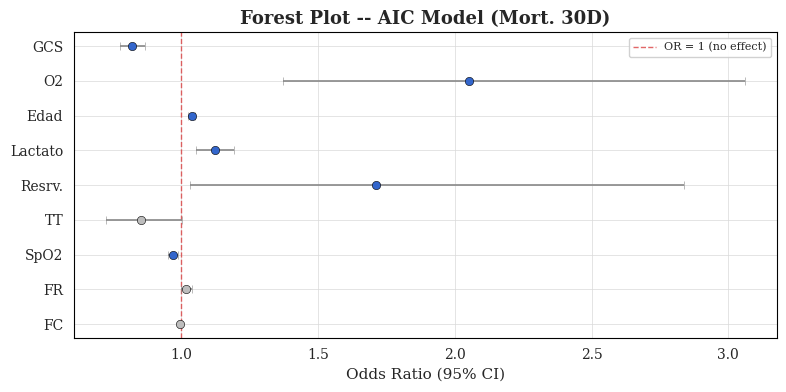


Significant predictors (p < 0.05): 6/9
Non-significant (consider excluding): ['TT', 'FR', 'FC']
Strongest predictors (|log OR| > 0.5): ['O2', 'Resrv.']


In [ ]:
"""
PURPOSE : Rank AIC-selected variables by significance, effect size, and precision.
INPUT   : sm_aic -- fitted statsmodels Logit result from AIC selection.
OUTPUT  : Ranked summary table + Zhang-styled forest plot of Odds Ratios.
"""

# Build ranking table
coef_full = coef_table_sm_full(sm_aic, drop_const=True)
coef_full["abs_log_OR"]   = np.abs(coef_full["beta"])
coef_full["CI_width"]     = coef_full["CI_high"] - coef_full["CI_low"]
coef_full["significant"]  = coef_full["p_value"] < 0.05
coef_full["OR_crosses_1"] = (coef_full["OR_CI_low"] <= 1) & (coef_full["OR_CI_high"] >= 1)

coef_full["rank_p"]  = coef_full["p_value"].rank()
coef_full["rank_OR"] = coef_full["abs_log_OR"].rank(ascending=False)
coef_full["rank_composite"] = (coef_full["rank_p"] + coef_full["rank_OR"]) / 2
coef_full = coef_full.sort_values("rank_composite")

display(Markdown(f"### Variable ranking -- {TARGET_COL}"))
rank_cols = ["variable", "beta", "se", "p_value", "OR", "OR_CI_low", "OR_CI_high",
             "significant", "OR_crosses_1"]
display(coef_full[rank_cols].round(4).reset_index(drop=True))

# ── Forest plot (Zhang theme_bw style) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(coef_full))))
y_pos = range(len(coef_full))

for yi, (_, row) in zip(y_pos, coef_full.iterrows()):
    clr = TFG_COLORS["loess_curve"] if row["significant"] else "#bdbdbd"
    ax.errorbar(row["OR"], yi,
                xerr=[[row["OR"] - row["OR_CI_low"]], [row["OR_CI_high"] - row["OR"]]],
                fmt="o", color=clr, ecolor="#888888", elinewidth=1.2, capsize=3, ms=6,
                markeredgecolor="black", markeredgewidth=0.4, zorder=5)

ax.axvline(1.0, color=TFG_COLORS["ref_line"], linestyle="--", lw=1, alpha=0.7,
           label="OR = 1 (no effect)")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_full["variable"].values)
ax.set_xlabel("Odds Ratio (95% CI)")
ax.set_title(f"Forest Plot -- AIC Model ({TARGET_COL})")
ax.legend(fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
_save_fig(fig, f"fig_05_forest_plot_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")

n_sig = coef_full["significant"].sum()
print(f"\nSignificant predictors (p < 0.05): {n_sig}/{len(coef_full)}")
non_sig = coef_full[~coef_full["significant"]]["variable"].tolist()
if non_sig:
    print(f"Non-significant (consider excluding): {non_sig}")
strong = coef_full[(coef_full["significant"]) & (coef_full["abs_log_OR"] > 0.5)]["variable"].tolist()
if strong:
    print(f"Strongest predictors (|log OR| > 0.5): {strong}")

## **6. K-Means clustering (optional section)**

K-Means partitions patients into k non-overlapping clusters by minimising within-cluster sum of squared Euclidean distances (inertia).

**Preprocessing**: median imputation + z-score standardisation (K-Means is distance-based and scale-sensitive).

**Model selection**: elbow method (inertia) + silhouette score over k ∈ {2, …, 8}. Optimal k = 3 was consistently identified.

**Validation**: PCA 2D projection, feature heatmap (z-scored cluster medians), mortality rates by cluster.

### Output

| Variable | Type | Description |
|----------|------|-------------|
| `df["Cluster_kmeans_k3"]` | `int` | Cluster assignment per patient |
| Elbow + silhouette plots | plot | Model selection diagnostics |
| Feature heatmap | plot | Cluster signatures |
| Mortality table | `pd.DataFrame` | Event rates per cluster per outcome |

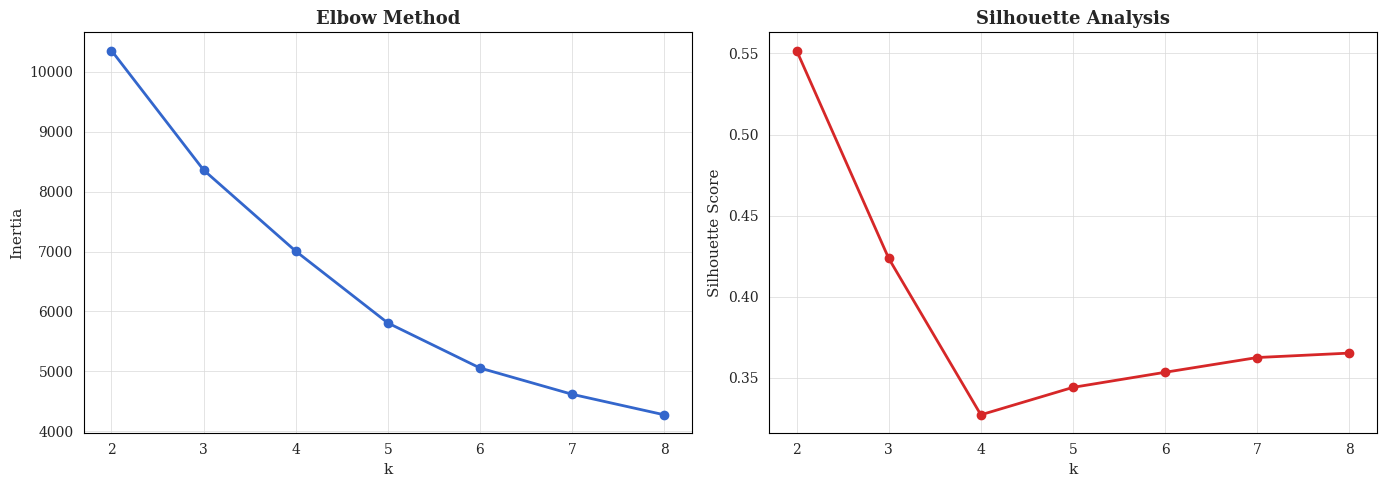

Cluster distribution:
Cluster_kmeans_k3
0    1795
1     371
2     210
Name: count, dtype: int64

Median feature values per cluster:


,Edad,GCS,Lactato,SpO2,Resrv.,O2
Cluster_kmeans_k3,,,,,,
0,66.0,15.0,2.7,97.0,0.0,0.0
1,77.0,15.0,3.1,91.0,0.0,1.0
2,73.0,10.0,4.8,82.0,1.0,1.0


In [ ]:
# NOTE: Clustering is purely descriptive/exploratory and does NOT feed
# the scoring model (§10). It is intentionally fitted on the full dataset
# to maximise cluster stability and visual clarity. No information from
# cluster labels leaks into the train/test scoring pipeline.
cluster_features = FEATURES
outcomes = ALL_MORT_COLS

# Preprocessing pipeline (clustering only — does not modify df)
preprocess_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

X_cluster = df[cluster_features].copy()
X_scaled  = preprocess_pipe.fit_transform(X_cluster)

# Elbow + silhouette
Ks = range(2, 9)
inertias, silhouettes = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000,
                                         random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(Ks), inertias, "o-", color=TFG_COLORS["loess_curve"], lw=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method", fontweight="bold")
axes[1].plot(list(Ks), silhouettes, "o-", color=TFG_COLORS["ref_line"], lw=2)
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis", fontweight="bold")
plt.tight_layout()
_save_fig(fig, "fig_06_kmeans_elbow_silhouette.png")

# Fit k=3
k_opt = 3
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
df[f"Cluster_kmeans_k{k_opt}"] = km_final.fit_predict(X_scaled)

print("Cluster distribution:")
print(df[f"Cluster_kmeans_k{k_opt}"].value_counts().sort_index())
print("\nMedian feature values per cluster:")
display(df.groupby(f"Cluster_kmeans_k{k_opt}")[cluster_features].median().round(2))

### K-Means validation — mortality rates and visualisation

Four views characterise the three K-Means clusters:

| Panel | Content | Purpose |
|-------|---------|---------|
| PCA scatter | 2D projection of standardised space, coloured by cluster | Geometric separation |
| Feature heatmap | Z-scored cluster medians per predictor | Cluster signature profiles |
| Medians ± IQR bar chart | Key variables: GCS, Lactato, SpO2, Edad | Clinical characterisation |
| Mortality stacked bars | Event rates per cluster per outcome | Clinical validity |

> Clustering is fitted on `df` (full dataset) for maximum stability.
> Cluster labels are **not** fed to the scoring model (§10); they serve descriptive purposes only.



── Mort. 2D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,21,1795,1.17
1,28,371,7.55
2,65,210,30.95



── Mort. 7D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,49,1795,2.73
1,40,371,10.78
2,84,210,40.00



── Mort. 30D ──


,Events,N,Mortality %
Cluster_kmeans_k3,,,
0,88,1795,4.90
1,69,371,18.60
2,104,210,49.52


/tmp/ipykernel_2379/1281370851.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


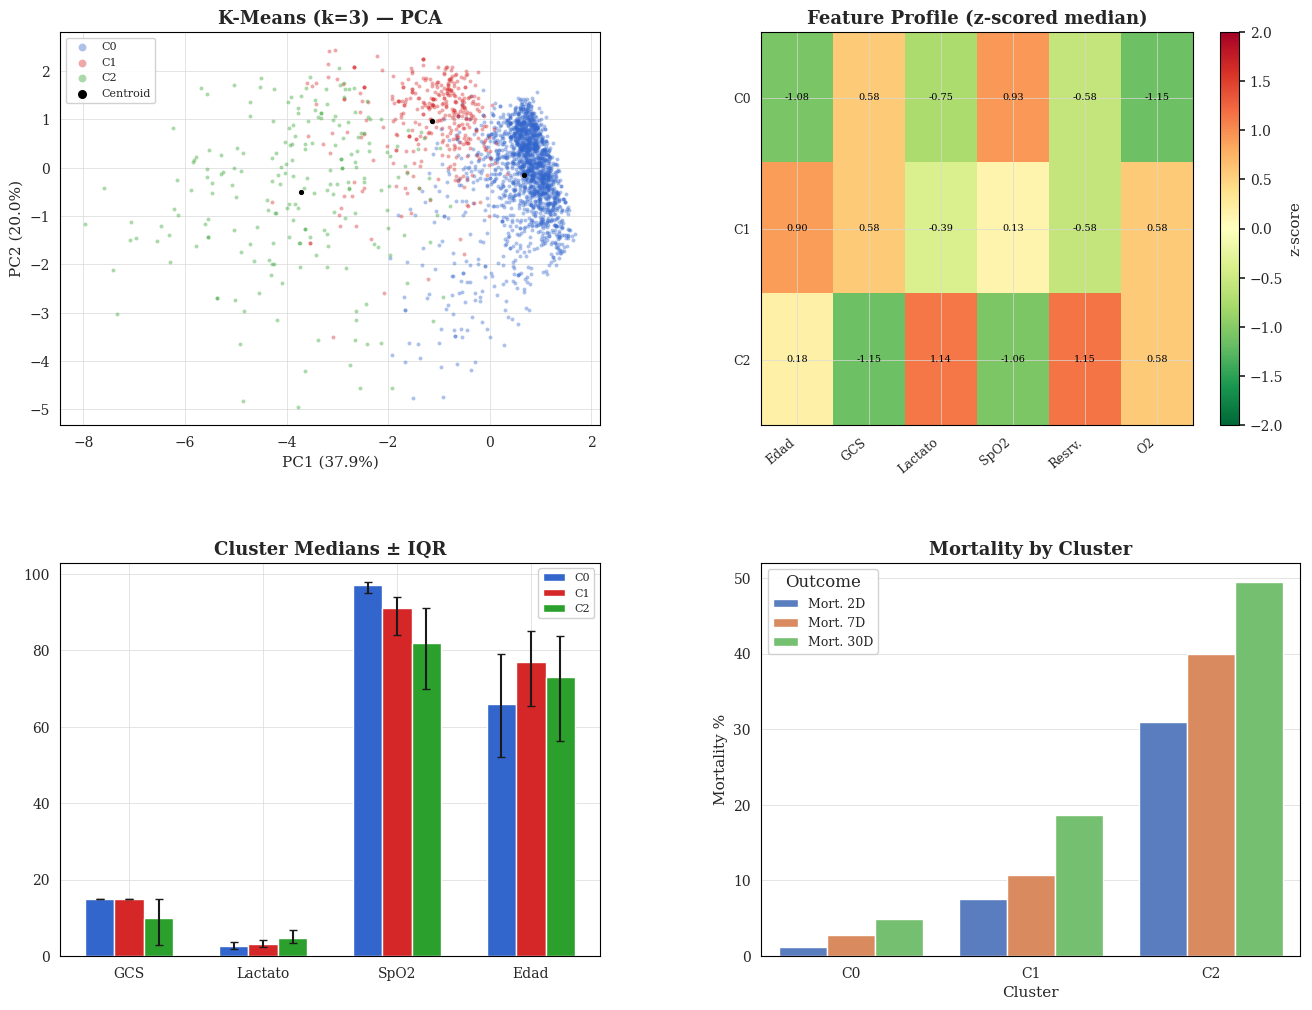

In [ ]:
k = 3
cluster_col = f"Cluster_kmeans_k{k}"

# Mortality by cluster
for oc in ALL_MORT_COLS:
    if oc not in df.columns:
        continue
    tab = df.groupby(cluster_col)[oc].agg(["sum", "count", "mean"])
    tab["mean"] = (tab["mean"] * 100).round(2)
    tab.columns = ["Events", "N", "Mortality %"]
    print(f"\n── {oc} ──")
    display(tab)

# 4-panel visualisation
colors_k = [TFG_COLORS["loess_curve"], TFG_COLORS["ref_line"], TFG_COLORS["cutpoint"]]
labels_k = {0: "C0", 1: "C1", 2: "C2"}

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# PCA scatter
ax1 = fig.add_subplot(gs[0, 0])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
for c in range(k):
    mask = df[cluster_col].values == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], s=8, alpha=0.4,
                color=colors_k[c], label=labels_k[c], linewidths=0)
centroids_pca = pca.transform(km_final.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=30, marker=".", color="black", zorder=5, label="Centroid")
var_exp = pca.explained_variance_ratio_
ax1.set_xlabel(f"PC1 ({var_exp[0]:.1%})"); ax1.set_ylabel(f"PC2 ({var_exp[1]:.1%})")
ax1.set_title("K-Means (k=3) — PCA", fontweight="bold")
ax1.legend(fontsize=8, markerscale=2); # grid inherited from Zhang style

# Feature heatmap
ax2 = fig.add_subplot(gs[0, 1])
cluster_medians = (df.groupby(cluster_col)[cluster_features]
                   .apply(lambda g: g.apply(pd.to_numeric, errors="coerce").median())
                   .apply(lambda col: (col - col.mean()) / (col.std() + 1e-8)))
im = ax2.imshow(cluster_medians.values.astype(float), cmap="RdYlGn_r", aspect="auto",
                vmin=-2, vmax=2)
ax2.set_xticks(range(len(cluster_features)))
ax2.set_xticklabels(cluster_features, rotation=40, ha="right", fontsize=9)
ax2.set_yticks(range(k))
ax2.set_yticklabels([labels_k[i] for i in range(k)], fontsize=9)
ax2.set_title("Feature Profile (z-scored median)", fontweight="bold")
plt.colorbar(im, ax=ax2, label="z-score")
for i in range(k):
    for j in range(len(cluster_features)):
        val = cluster_medians.iloc[i, j]
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=7, color="white" if abs(val) > 1.2 else "black")

# Boxplots
ax3 = fig.add_subplot(gs[1, 0])
key_vars = ["GCS", "Lactato", "SpO2", "Edad"]
n_vars = len(key_vars); width = 0.22; x = np.arange(n_vars)
for c in range(k):
    mask = df[cluster_col] == c
    medians = [df.loc[mask, v].median() for v in key_vars]
    q25 = [df.loc[mask, v].quantile(0.25) for v in key_vars]
    q75 = [df.loc[mask, v].quantile(0.75) for v in key_vars]
    errs = [[m - q for m, q in zip(medians, q25)], [q - m for m, q in zip(medians, q75)]]
    ax3.bar(x + c * width, medians, width, label=labels_k[c], color=colors_k[c],
            yerr=errs, capsize=3)
ax3.set_xticks(x + width); ax3.set_xticklabels(key_vars)
ax3.set_title("Cluster Medians ± IQR", fontweight="bold")
ax3.legend(fontsize=8)

# Mortality bars
ax4 = fig.add_subplot(gs[1, 1])
mort_data = []
for oc in ALL_MORT_COLS:
    if oc not in df.columns:
        continue
    for c in range(k):
        mask = df[cluster_col] == c
        rate = df.loc[mask, oc].mean() * 100
        mort_data.append({"Outcome": oc, "Cluster": labels_k[c], "Mortality %": rate})
mort_df = pd.DataFrame(mort_data)
if not mort_df.empty:
    sns.barplot(data=mort_df, x="Cluster", y="Mortality %", hue="Outcome",
                palette="muted", ax=ax4)
    ax4.set_title("Mortality by Cluster", fontweight="bold")

plt.tight_layout()
_save_fig(fig, "fig_06_kmeans_validation_panels.png")

## **7. FAMD + Ward hierarchical clustering (optional section)**

The dataset contains mixed-type variables: continuous (*Edad*, *GCS*, *Lactato*, *SpO2*, *TT*, *FR*), binary (O2), and nominal categorical (*Ritmo*, *ST*). FAMD generalises PCA to handle all three types simultaneously, producing a Euclidean embedding suitable for Ward's agglomerative hierarchical clustering.

### Function: `famd_ward_pipeline()`

| Parameter | Value | Description |
|-----------|-------|-------------|
| `features` | `FEATURES` | Active feature set for the selected outcome |
| `k` | `3` | Number of clusters |
| `n_components` | `8` | FAMD dimensions retained |
| `cat_override` | `CATEGORICAL_VARS` | Columns forced to categorical regardless of dtype |

### Output

Validation metrics (silhouette, Calinski-Harabasz, Davies-Bouldin), FAMD scatter,
Ward dendrogram, PCA projection in original feature space, cluster heatmap,
and mortality rates per cluster.


In [ ]:
def to_event_binary(series: pd.Series) -> pd.Series:
    """Convert a mortality column to binary (0/1), handling bool/str/int."""
    s = series.copy()
    if s.dtype == bool:
        return s.astype(int)
    if s.dtype == object:
        s = s.str.strip().str.lower().map({"si": 1, "sí": 1, "yes": 1, "1": 1,
                                            "no": 0, "0": 0})
    return pd.to_numeric(s, errors="coerce")


def famd_ward_pipeline(
    df: pd.DataFrame, features: Sequence[str], k: int = 3,
    n_components: int = 8, random_state: int = 42,
    cat_override: Optional[Sequence[str]] = None,
) -> Dict[str, object]:
    """FAMD + Ward clustering pipeline. Returns dict with features, famd, X_f, Z, labels, metrics.

    Parameters
    ----------
    cat_override : columns to force-treat as categorical regardless of dtype.
                   Defaults to an empty list if not provided.
    """
    _cat_override = set(cat_override) if cat_override is not None else set()

    feats = [c for c in features if c in df.columns]
    X = df[feats].copy()
    num_cols = [c for c in feats if c not in _cat_override
                and X[c].dtype.kind in "iufc" and X[c].nunique(dropna=True) > 2]
    cat_cols = [c for c in feats if c not in num_cols]
    if num_cols:
        X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
        X[num_cols] = StandardScaler().fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        for c in cat_cols:
            X[c] = X[c].astype("category")
    n_comp = min(n_components, len(feats))
    famd = prince.FAMD(n_components=n_comp, n_iter=10, random_state=random_state).fit(X)
    X_f = famd.row_coordinates(X)
    Z = linkage(X_f.values, method="ward")
    labels = fcluster(Z, t=k, criterion="maxclust") - 1
    metrics = {
        "silhouette":        float(silhouette_score(X_f.values, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X_f.values, labels)),
        "davies_bouldin":    float(davies_bouldin_score(X_f.values, labels)),
    }
    return {"features": feats, "famd": famd, "X_f": X_f, "Z": Z,
            "labels": labels, "metrics": metrics}


def plot_famd_scatter(X_f: pd.DataFrame, labels: np.ndarray, title: str,
                       fname: str = "") -> None:
    fig, ax = plt.subplots(figsize=(6, 5))
    palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
    for i, lab in enumerate(np.unique(labels)):
        mask = labels == lab
        ax.scatter(X_f.iloc[mask, 0], X_f.iloc[mask, 1],
                   s=12, alpha=0.6, color=palette[i], label=f"Cluster {lab}")
    ax.set_xlabel("FAMD Dim 1"); ax.set_ylabel("FAMD Dim 2")
    ax.set_title(title); ax.legend()
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show(); plt.close(fig)


def plot_dendrogram(Z: np.ndarray, k: int, title: str,
                    fname: str = "") -> None:
    fig, ax = plt.subplots(figsize=(11, 4))
    cut_height = sorted(Z[:, 2], reverse=True)[k - 1]
    dendrogram(Z, no_labels=True, ax=ax, color_threshold=cut_height)
    ax.axhline(y=cut_height, color="red", linestyle="--", linewidth=1.2, label=f"Cut at k={k}")
    ax.set_title(title); ax.set_ylabel("Ward distance"); ax.legend()
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show(); plt.close(fig)


def plot_mortality_bars(df: pd.DataFrame, cluster_col: str,
                        mort_cols: Sequence[str]) -> None:
    rows = []
    for m in mort_cols:
        if m not in df.columns:
            continue
        y = to_event_binary(df[m])
        tmp = pd.DataFrame({cluster_col: df[cluster_col], m: y}).dropna()
        rate = tmp.groupby(cluster_col)[m].mean() * 100
        for cid, val in rate.items():
            rows.append({"Outcome": m, "Cluster": cid, "Mortality (%)": float(val)})
    out = pd.DataFrame(rows)
    if out.empty:
        return
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(data=out, x="Cluster", y="Mortality (%)", hue="Outcome",
                palette="muted", ax=ax)
    ax.set_title("Mortality rate by cluster")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_mortality_bars.png")


def plot_famd_variance(famd: prince.FAMD, title: str,
                       fname: str = "") -> None:
    if hasattr(famd, "explained_inertia_"):
        ev = np.array(famd.explained_inertia_)
    else:
        ev = np.array(famd.eigenvalues_) / np.array(famd.eigenvalues_).sum()
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(range(1, len(ev) + 1), ev * 100, color="steelblue")
    ax.set_xlabel("Component"); ax.set_ylabel("Explained inertia (%)")
    ax.set_title(title)
    plt.tight_layout()
    if fname:
        _save_fig(fig, fname)
    else:
        plt.show(); plt.close(fig)


def plot_pca_clusters(df: pd.DataFrame, features: Sequence[str],
                      cluster_col: str,
                      cat_override: Optional[Sequence[str]] = None) -> None:
    _cat_override = set(cat_override) if cat_override is not None else set()

    feats = [f for f in features if f in df.columns]
    X = df[feats].copy()
    num_cols = [c for c in feats if c not in _cat_override
                and X[c].dtype.kind in "iufc" and X[c].nunique(dropna=True) > 2]
    cat_cols = [c for c in feats if c not in num_cols]
    X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
    X[num_cols] = StandardScaler().fit_transform(X[num_cols])
    if cat_cols:
        X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)
    var = pca.explained_variance_ratio_ * 100
    labels = df[cluster_col].values
    palette = sns.color_palette("tab10", n_colors=len(np.unique(labels)))
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, cl in enumerate(sorted(np.unique(labels))):
        mask = labels == cl
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=12, alpha=0.6, color=palette[i], label=f"Cluster {cl}")
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title("PCA — clusters in original feature space")
    ax.legend(title="Cluster")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_pca_clusters.png")


def plot_cluster_heatmap(df: pd.DataFrame, features: Sequence[str],
                         cluster_col: str) -> None:
    feats = [f for f in features if f in df.columns]
    med = df.groupby(cluster_col)[feats].median()
    z = (med - med.mean()) / (med.std() + 1e-8)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    sns.heatmap(z, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, ax=ax)
    ax.set_title("Cluster profile heatmap (z-scored medians)")
    plt.tight_layout()
    _save_fig(fig, "fig_07_famd_cluster_heatmap.png")

### FAMD + Ward — execution and visualisation

**Parameters used:**
- `K = 3` — consistent with K-Means optimal k (§6).
- `n_components = 8` — typically retains ≥ 80 % inertia.
- `cat_override = CATEGORICAL_VARS` — forces `Ritmo` / `ST` to categorical within FAMD.

**Plots produced (saved to OUTPUT_DIR):**

| Plot | Filename |
|------|----------|
| FAMD Dim 1 × Dim 2 scatter | `fig_07_famd_scatter.png` |
| Ward dendrogram | `fig_07_famd_dendrogram.png` |
| FAMD explained inertia | `fig_07_famd_variance.png` |
| PCA projection (original feature space) | `fig_07_famd_pca_clusters.png` |
| Feature profile heatmap (z-scored medians) | `fig_07_famd_cluster_heatmap.png` |
| Mortality rate bars | `fig_07_famd_mortality_bars.png` |


FAMD + Ward  (k=3)
  Silhouette        : 0.4093
  Calinski-Harabasz : 795.12
  Davies-Bouldin    : 1.1624


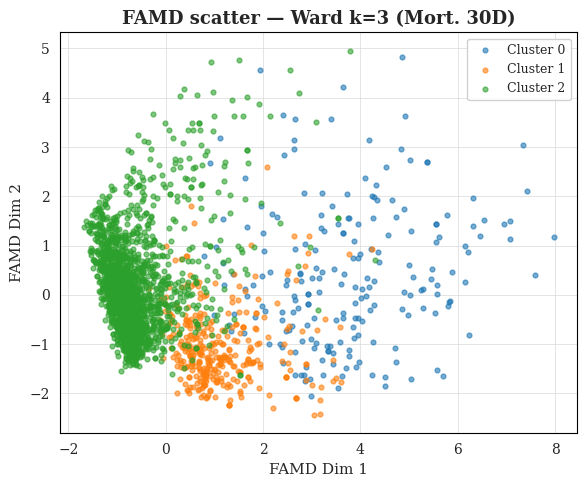

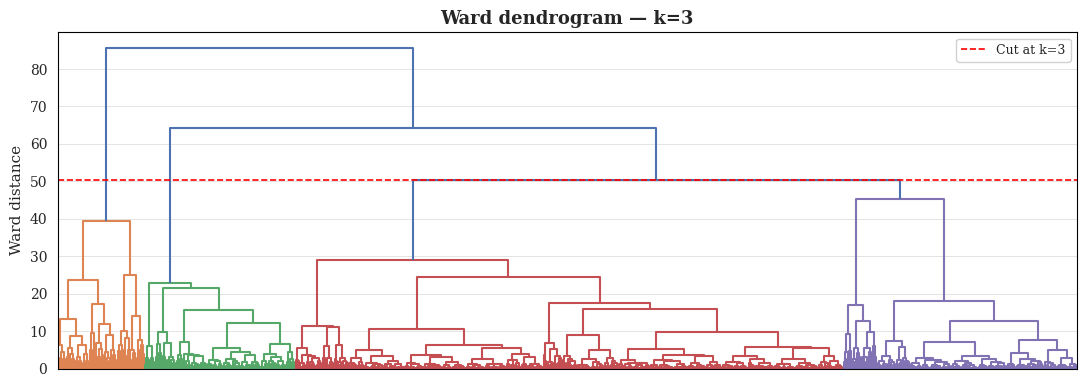

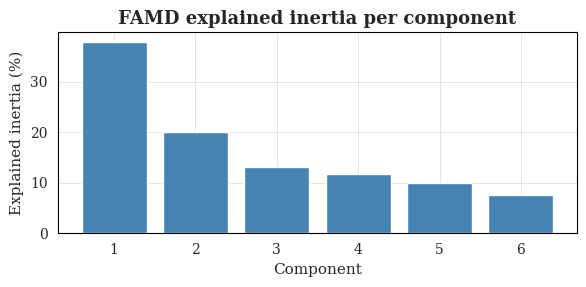

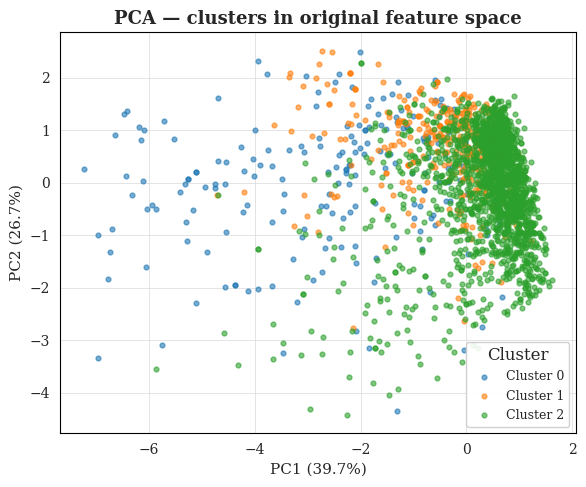

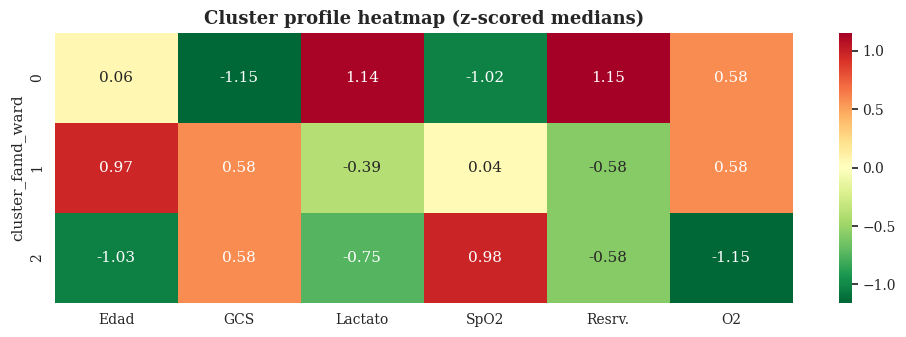

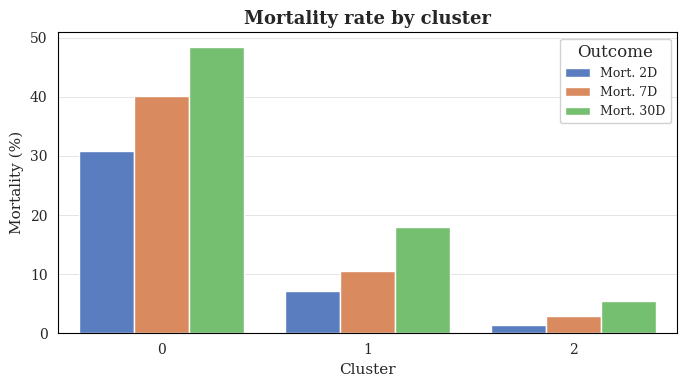

In [ ]:
# ── FAMD + Ward clustering ───────────────────────────────────────────────────
# Runs on the full dataset for maximum cluster stability.
# cat_override ensures Ritmo and ST are treated as categorical by FAMD
# regardless of their storage dtype in the DataFrame.

K = 3
res = famd_ward_pipeline(
    df, FEATURES, k=K, n_components=8,
    random_state=RANDOM_STATE,
    cat_override=list(CATEGORICAL_VARS),
)
df["cluster_famd_ward"] = res["labels"]

print(f"FAMD + Ward  (k={K})")
print(f"  Silhouette        : {res['metrics']['silhouette']:.4f}")
print(f"  Calinski-Harabasz : {res['metrics']['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin    : {res['metrics']['davies_bouldin']:.4f}")

cluster_col_fw = "cluster_famd_ward"
plot_famd_scatter(res["X_f"], res["labels"],
                  title=f"FAMD scatter — Ward k={K} ({TARGET_COL})",
                  fname="fig_07_famd_scatter.png")
plot_dendrogram(res["Z"], K,
                title=f"Ward dendrogram — k={K}",
                fname="fig_07_famd_dendrogram.png")
plot_famd_variance(res["famd"],
                   title="FAMD explained inertia per component",
                   fname="fig_07_famd_variance.png")
plot_pca_clusters(df, FEATURES, cluster_col_fw,
                  cat_override=list(CATEGORICAL_VARS))
plot_cluster_heatmap(df, [v for v in FEATURES if v not in CATEGORICAL_VARS],
                     cluster_col_fw)
plot_mortality_bars(df, cluster_col_fw, ALL_MORT_COLS)


## **8. Cutpoint identification via LOESS**

This section provides **visual diagnostics** for continuous variable risk curves:

1. **Top panel**: raw events (jittered), LOESS smoothed risk curve, 95 % Bayesian interval
2. **Bottom panel**: event density along X

Cut-points used downstream (**section 9.**) are taken from `CLINICAL_CUTS_PER_OUTCOME` (defined in **section 2**).

>LOESS candidate cuts shown here in grey are for visual reference only and are only used as a fallback if no clinical cut is defined.

>Green dashed lines represent the **active cut-points** that will be applied in §9.

### Visualisation improvements
- Deaths shown **inside** the \[0, 1\] area with jitter to avoid overplotting
- Density panel shows where deaths concentrate along X
- Cutpoints use a segment-aware greedy selection algorithm
- Monotonic constraints applied via `IsotonicRegression` (sklearn) or cumulative fallback


In [ ]:
# Conditional imports for LOESS utilities (core libs already in §1)
from statsmodels.nonparametric.smoothers_lowess import lowess

try:
    from sklearn.isotonic import IsotonicRegression
    _HAS_ISO = True
except ImportError:
    _HAS_ISO = False

try:
    from scipy.signal import savgol_filter
    _HAS_SCIPY_SIGNAL = True
except ImportError:
    _HAS_SCIPY_SIGNAL = False

try:
    from scipy.stats import beta as _beta_dist
    _HAS_SCIPY_BETA = True
except ImportError:
    _HAS_SCIPY_BETA = False


def _enforce_monotone(y: np.ndarray, direction: str) -> np.ndarray:
    """Fallback monotonic enforcement (no sklearn)."""
    y = np.asarray(y, dtype=float)
    if direction == "increasing":
        return np.maximum.accumulate(y)
    if direction == "decreasing":
        return np.minimum.accumulate(y)
    return y


def _beta_ci(deaths: np.ndarray, n: np.ndarray, a: float = 0.5, b: float = 0.5,
             alpha: float = 0.05) -> Tuple[np.ndarray, np.ndarray]:
    """
    Jeffreys-prior Beta posterior interval for a binomial proportion.
    Fast and stable even when counts are small.
    """
    deaths = np.asarray(deaths, dtype=float)
    n = np.asarray(n, dtype=float)
    aa = deaths + a
    bb = (n - deaths) + b

    if _HAS_SCIPY_BETA:
        lo = _beta_dist.ppf(alpha / 2, aa, bb)
        hi = _beta_dist.ppf(1 - alpha / 2, aa, bb)
        return lo, hi

    # Fallback: normal approx (less accurate in small n)
    p = aa / (aa + bb)
    se = np.sqrt(p * (1 - p) / np.maximum(n, 1))
    z = 1.96
    return np.clip(p - z * se, 0, 1), np.clip(p + z * se, 0, 1)


def _prepare_xy(df: pd.DataFrame, x_col: str, y_col: str,
                trim_percentile: float = 5.0) -> Tuple[np.ndarray, np.ndarray]:
    tmp = df[[x_col, y_col]].copy()
    tmp[x_col] = pd.to_numeric(tmp[x_col], errors="coerce")
    y01 = to_event_binary(tmp[y_col])
    tmp["_y01"] = y01
    tmp = tmp.dropna(subset=[x_col, "_y01"]).sort_values(x_col)

    x = tmp[x_col].to_numpy(dtype=float)
    y = tmp["_y01"].to_numpy(dtype=float)

    if len(x) == 0:
        return x, y

    lo = np.percentile(x, trim_percentile)
    hi = np.percentile(x, 100 - trim_percentile)
    keep = (x >= lo) & (x <= hi)
    return x[keep], y[keep]


def _bin_event_rate(
    x: np.ndarray,
    y: np.ndarray,
    n_bins: int = 70,
    min_bin_n: int = 25,
    bayes_a: float = 0.5,
    bayes_b: float = 0.5
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bin X and compute:
      - bin_x      median X per bin
      - bin_rate   smoothed (Bayesian) event rate per bin
      - bin_d      deaths per bin
      - bin_n      N per bin
      - ci_low/hi  Beta posterior interval for each bin (raw, before LOWESS)
    """
    if len(x) < 200:
        return (np.array([]),) * 6

    # Prefer quantile bins to avoid empty bins in long-tailed vars
    try:
        bins = pd.qcut(x, q=n_bins, duplicates="drop")
    except Exception:
        bins = pd.cut(x, bins=n_bins)

    s = pd.DataFrame({"x": x, "y": y, "bin": bins})
    g = s.groupby("bin", observed=True)

    bin_x = g["x"].median().to_numpy()
    bin_n = g.size().to_numpy()
    bin_d = g["y"].sum().to_numpy()

    keep = bin_n >= min_bin_n
    bin_x, bin_n, bin_d = bin_x[keep], bin_n[keep], bin_d[keep]

    if len(bin_x) < 12:
        return (bin_x, np.array([]), bin_d, bin_n, np.array([]), np.array([]))

    order = np.argsort(bin_x)
    bin_x, bin_n, bin_d = bin_x[order], bin_n[order], bin_d[order]

    # Bayesian-smoothed rate
    bin_rate = (bin_d + bayes_a) / (bin_n + bayes_a + bayes_b)

    ci_low, ci_hi = _beta_ci(bin_d, bin_n, a=bayes_a, b=bayes_b, alpha=0.05)
    return bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi


def _lowess_smooth(x: np.ndarray, y: np.ndarray, frac: float, it: int = 0) -> np.ndarray:
    return np.clip(lowess(y, x, frac=frac, it=it, return_sorted=False), 0, 1)


def _smooth_for_derivatives(y: np.ndarray, window_frac: float = 0.14) -> np.ndarray:
    """
    Stabilise derivatives. If SciPy is available, use Savitzky-Golay.
    Otherwise, fall back to a simple rolling mean.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 9:
        return y

    if _HAS_SCIPY_SIGNAL:
        w = max(9, int(round(window_frac * n)))
        if w % 2 == 0:
            w += 1
        w = min(w, n - 1 if (n - 1) % 2 == 1 else n - 2)
        w = max(w, 9)
        return savgol_filter(y, window_length=w, polyorder=2, mode="interp")

    # fallback rolling
    k = max(5, int(round(window_frac * n)))
    return pd.Series(y).rolling(k, center=True, min_periods=1).mean().to_numpy()


def _rank_cut_candidates(
    bin_x: np.ndarray,
    sm: np.ndarray,
    bin_d: np.ndarray,
    bin_n: np.ndarray,
    max_candidates: int = 25,
    min_zone_n: int = 50,
    min_risk_delta: float = 0.01,
    min_risk_level: float = 0.02,
    edge_exclude_frac: float = 0.06,
) -> pd.DataFrame:
    """
    Score candidates at each bin index i (cut at bin_x[i]) using:
      - risk jump (left vs right)
      - death balance (min deaths left/right)
      - curvature (second derivative magnitude)
    Returns a ranked table for human inspection.
    """
    if len(bin_x) < 12:
        return pd.DataFrame()

    sm2 = _smooth_for_derivatives(sm)
    d1 = np.gradient(sm2, bin_x)
    d2 = np.gradient(d1, bin_x)
    curv = np.abs(d2)

    n_bins = len(bin_x)
    edge = int(round(edge_exclude_frac * n_bins))
    edge = max(edge, 2)

    rows = []
    csum_n = np.cumsum(bin_n)
    csum_d = np.cumsum(bin_d)
    total_n = float(csum_n[-1])
    total_d = float(csum_d[-1])

    for i in range(edge, n_bins - edge - 1):
        left_n = float(csum_n[i])
        right_n = float(total_n - left_n)
        if left_n < min_zone_n or right_n < min_zone_n:
            continue

        left_d = float(csum_d[i])
        right_d = float(total_d - left_d)

        left_rate = left_d / left_n if left_n > 0 else 0.0
        right_rate = right_d / right_n if right_n > 0 else 0.0
        delta = abs(right_rate - left_rate)

        if delta < min_risk_delta:
            continue
        if max(left_rate, right_rate) < min_risk_level:
            continue

        death_balance = min(left_d, right_d)
        score = (delta * (death_balance + 1.0) ** 0.5 * (curv[i] + 1e-9) ** 0.35)

        rows.append({
            "cut_x": float(bin_x[i]),
            "score": float(score),
            "delta_rate": float(delta),
            "left_n": int(left_n),
            "right_n": int(right_n),
            "left_deaths": int(left_d),
            "right_deaths": int(right_d),
            "left_rate": float(left_rate),
            "right_rate": float(right_rate),
            "curvature": float(curv[i]),
            "idx": int(i),
        })

    if not rows:
        return pd.DataFrame()

    out = (pd.DataFrame(rows)
             .sort_values("score", ascending=False)
             .reset_index(drop=True))

    return out.head(max_candidates)


def loess_cutpoints_v2(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_bins: int = 70,
    frac: Optional[float] = None,
    it: int = 0,
    bayes_a: float = 0.5,
    bayes_b: float = 0.5,
    min_bin_n: int = 25,
    trim_percentile: float = 5.0,
    max_cuts: int = 3,
    min_gap_frac: float = 0.15,
    min_risk_delta: float = 0.01,
    min_zone_n: int = 50,
    min_risk_level: float = 0.02,
    monotonic: Optional[str] = None,
) -> Dict:
    """
    Returns a dict with everything needed for plotting + cutpoint inspection:
      - bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi
      - sm, sm_ci_low, sm_ci_hi (LOWESS-smoothed)
      - candidates (ranked DataFrame)
      - cuts (selected list)
    """
    x, y = _prepare_xy(df, x_col, y_col, trim_percentile=trim_percentile)
    if len(x) < 200:
        return dict(bin_x=np.array([]), cuts=[], candidates=pd.DataFrame())

    bin_x, bin_rate, bin_d, bin_n, ci_low, ci_hi = _bin_event_rate(
        x, y, n_bins=n_bins, min_bin_n=min_bin_n, bayes_a=bayes_a, bayes_b=bayes_b
    )
    if len(bin_x) < 12 or len(bin_rate) == 0:
        return dict(bin_x=bin_x, bin_rate=bin_rate, bin_d=bin_d, bin_n=bin_n,
                    ci_low=ci_low, ci_hi=ci_hi, cuts=[], candidates=pd.DataFrame())

    if frac is None:
        # heuristic: keep a ~10-point neighbourhood, bounded
        frac = float(np.clip(10 / len(bin_x), 0.10, 0.28))

    sm = _lowess_smooth(bin_x, bin_rate, frac=frac, it=it)
    sm_lo = _lowess_smooth(bin_x, ci_low, frac=frac, it=it)
    sm_hi = _lowess_smooth(bin_x, ci_hi, frac=frac, it=it)

    # Monotonic enforcement (prevents sparse-tail drops)
    if monotonic in {"increasing", "decreasing"}:
        if _HAS_ISO:
            inc = (monotonic == "increasing")
            iso = IsotonicRegression(increasing=inc, out_of_bounds="clip")
            sm = iso.fit_transform(bin_x, sm)
            sm_lo = iso.fit_transform(bin_x, sm_lo)
            sm_hi = iso.fit_transform(bin_x, sm_hi)
        else:
            sm = _enforce_monotone(sm, monotonic)
            sm_lo = _enforce_monotone(sm_lo, monotonic)
            sm_hi = _enforce_monotone(sm_hi, monotonic)

    cand = _rank_cut_candidates(
        bin_x, sm, bin_d, bin_n,
        max_candidates=30,
        min_zone_n=min_zone_n,
        min_risk_delta=min_risk_delta,
        min_risk_level=min_risk_level,
    )

    # Segment-aware greedy selection (avoids clustered cuts)
    cuts: List[float] = []
    if not cand.empty:
        x_range = float(bin_x[-1] - bin_x[0])
        min_gap = float(min_gap_frac * x_range)

        # segments as (left_idx, right_idx) inclusive
        segments = [(0, len(bin_x) - 1)]

        def best_in_segment(seg):
            l, r = seg
            cseg = cand[(cand["idx"] >= l + 2) & (cand["idx"] <= r - 3)].copy()
            if cseg.empty:
                return None
            return cseg.iloc[0]

        while len(cuts) < max_cuts:
            best_row = None
            best_seg = None

            for seg in segments:
                row = best_in_segment(seg)
                if row is None:
                    continue
                if (best_row is None) or (row["score"] > best_row["score"]):
                    best_row = row
                    best_seg = seg

            if best_row is None:
                break

            cx = float(best_row["cut_x"])
            if any(abs(cx - c) < min_gap for c in cuts):
                # invalidate this one and continue
                cand = cand[cand["cut_x"] != cx].reset_index(drop=True)
                if cand.empty:
                    break
                continue

            cuts.append(cx)
            cuts.sort()

            # split segment
            l, r = best_seg
            i = int(best_row["idx"])
            segments.remove(best_seg)
            segments.extend([(l, i), (i + 1, r)])

    return dict(
        x_raw=x,
        y_raw=y,
        bin_x=bin_x,
        bin_rate=bin_rate,
        bin_d=bin_d,
        bin_n=bin_n,
        ci_low=ci_low,
        ci_hi=ci_hi,
        sm=sm,
        sm_ci_low=sm_lo,
        sm_ci_hi=sm_hi,
        candidates=cand,
        cuts=cuts,
        frac=frac,
    )


> Savitzky-Golay smoothing is applied after LOESS to reduce residual
> oscillation in sparse regions. This affects visual presentation only;
> active cutpoints are defined in `CLINICAL_CUTS_PER_OUTCOME`, not derived
> from the smoothed curve.

Continuous variables for LOESS (Mort. 30D): ['Edad', 'Lactato', 'SpO2']


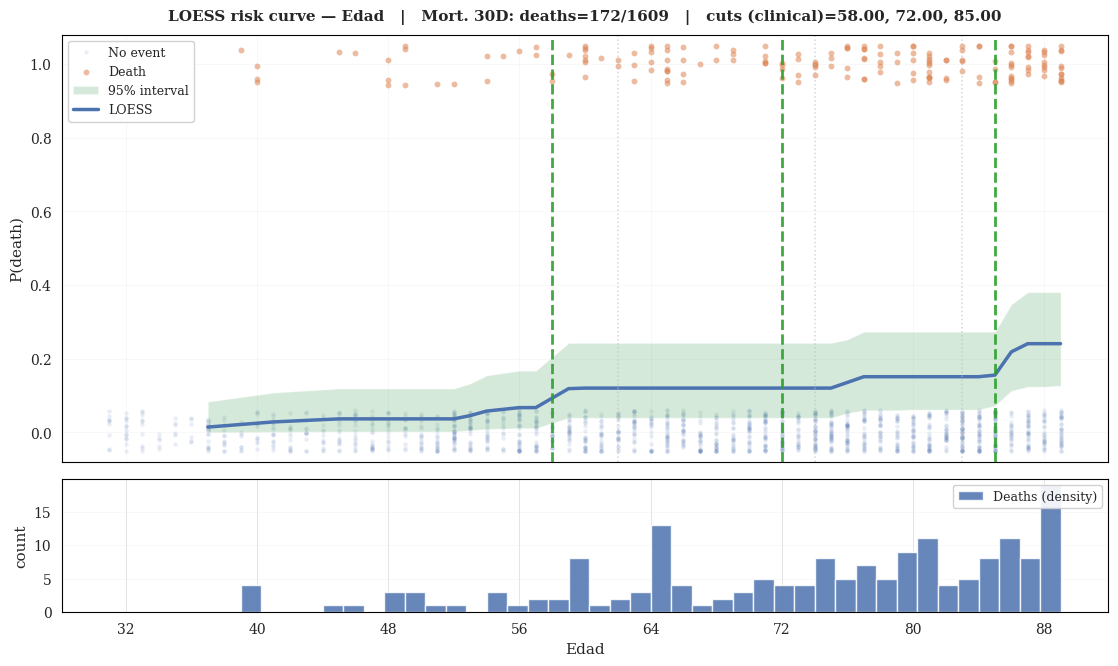

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,83.0,0.1006,0.0766,1099,259,111,46,0.1010,0.1776,0.0089
1,84.0,0.0991,0.0967,1145,213,115,42,0.1004,0.1972,0.0050
2,74.0,0.0720,0.0721,746,612,62,95,0.0831,0.1552,0.0027
3,82.0,0.0713,0.0603,1043,315,106,51,0.1016,0.1619,0.0057
4,73.0,0.0688,0.0699,698,660,57,100,0.0817,0.1515,0.0029
5,75.0,0.0636,0.0793,789,569,65,92,0.0824,0.1617,0.0013
6,85.0,0.0581,0.1430,1201,157,119,38,0.0991,0.2420,0.0004
7,62.0,0.0520,0.0842,342,1016,18,139,0.0526,0.1368,0.0038
8,63.0,0.0501,0.0818,373,985,21,136,0.0563,0.1381,0.0030
9,72.0,0.0487,0.0717,669,689,53,104,0.0792,0.1509,0.0011


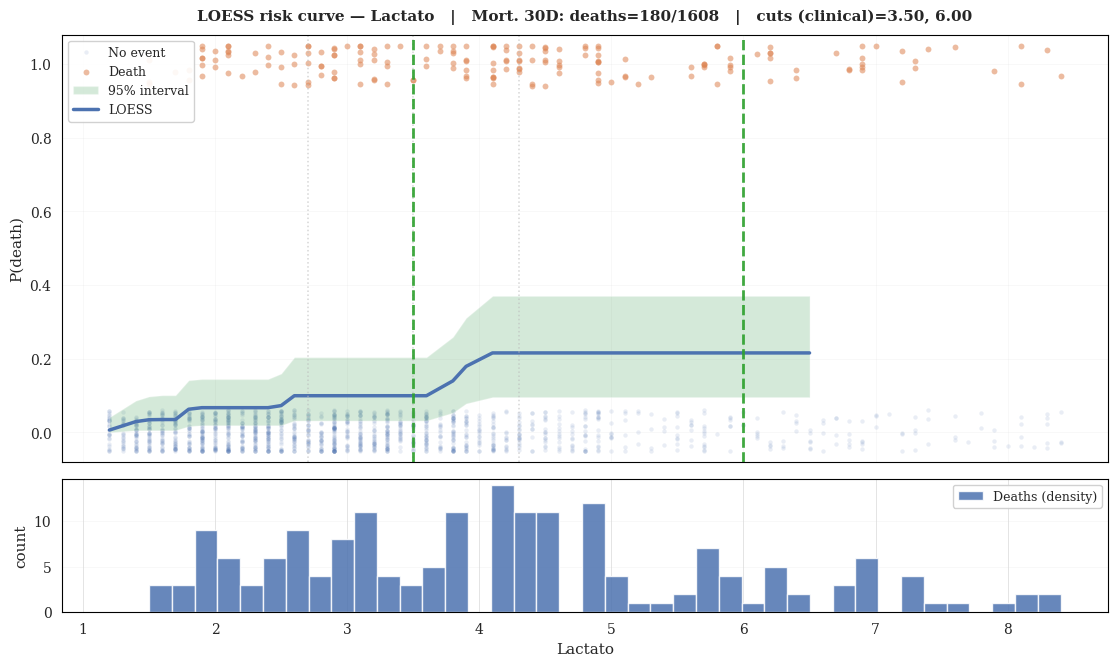

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,3.5,0.6497,0.1018,1064,306,69,51,0.0648,0.1667,0.7051
1,3.4,0.6170,0.0940,1036,334,67,53,0.0647,0.1587,0.7240
2,3.6,0.5971,0.1175,1107,263,72,48,0.0650,0.1825,0.4008
3,3.8,0.3953,0.1314,1153,217,77,43,0.0668,0.1982,0.1045
4,3.3,0.3573,0.0832,1007,363,66,54,0.0655,0.1488,0.2098
5,2.7,0.2766,0.0726,728,642,39,81,0.0536,0.1262,0.2352
6,4.3,0.2346,0.0928,1248,122,99,21,0.0793,0.1721,0.1709
7,2.4,0.2273,0.0760,601,769,27,93,0.0449,0.1209,0.1959
8,2.6,0.2034,0.0796,688,682,33,87,0.0480,0.1276,0.0947
9,2.2,0.1964,0.0654,485,885,22,98,0.0454,0.1107,0.2630


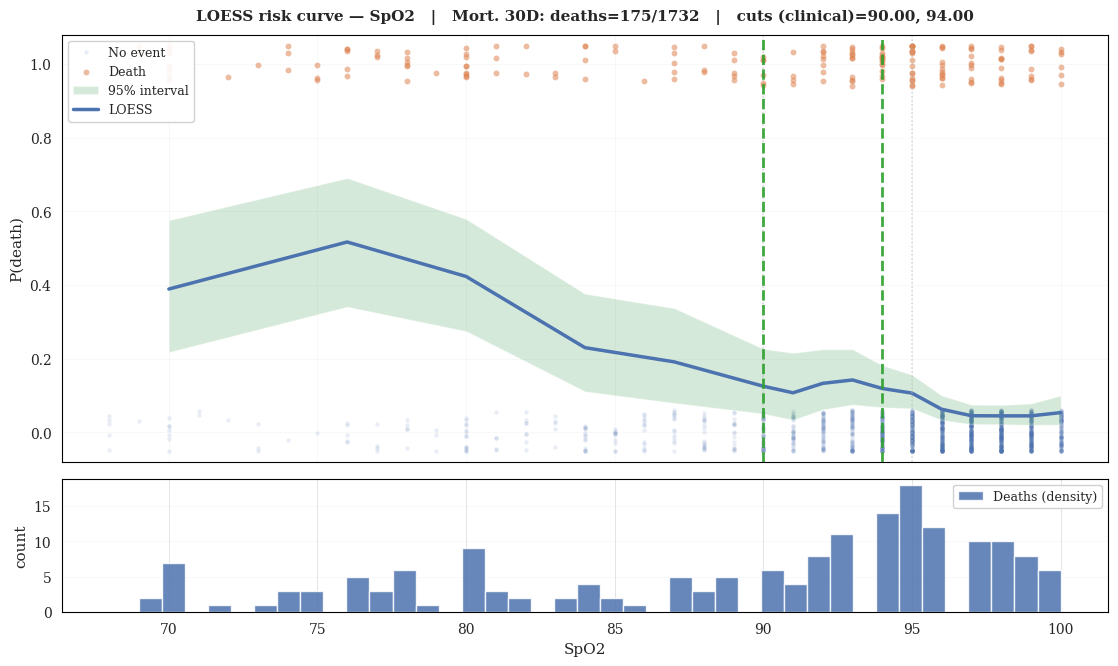

,cut_x,score,delta_rate,left_n,right_n,left_deaths,right_deaths,left_rate,right_rate,curvature
0,90.0,0.3590,0.2170,213,1456,61,101,0.2864,0.0694,0.0116
1,91.0,0.3284,0.1874,254,1415,65,97,0.2559,0.0686,0.0125
2,87.0,0.1762,0.2685,162,1507,55,107,0.3395,0.0710,0.0010
3,84.0,0.1695,0.3065,129,1540,49,113,0.3798,0.0734,0.0007
4,92.0,0.1358,0.1645,317,1352,73,89,0.2303,0.0658,0.0012
5,95.0,0.1144,0.1208,691,978,116,46,0.1679,0.0470,0.0035
6,96.0,0.0937,0.1002,890,779,128,34,0.1438,0.0436,0.0051
7,97.0,0.0635,0.0789,1123,546,138,24,0.1229,0.0440,0.0054
8,80.0,0.0550,0.3641,93,1576,41,121,0.4409,0.0768,0.0000



----------------------------------------------------------------------
Active cuts (Mort. 30D) summary:
  Edad        : [58.0, 72.0, 85.0]  (clinical)
  Lactato     : [3.5, 6.0]  (clinical)
  SpO2        : [90.0, 94.0]  (clinical)

Cutpoint source summary (Mort. 30D):
  Edad           : clinical
  Lactato        : clinical
  SpO2           : clinical


In [ ]:
"""
PURPOSE : LOESS cutpoint visualisation + candidate table (readable + diagnostic).

Plot layout:
  - Top panel: raw points (jittered), LOESS curve, 95% band, active cutpoints
  - Bottom panel: event density (histogram of deaths along X)
"""

import matplotlib.ticker as mticker

numeric_vars = [
    v for v in FEATURES
    if v not in BINARY_VARS and v not in GCS_VARS and v not in CATEGORICAL_VARS and v in df.columns
]
print(f"Continuous variables for LOESS ({TARGET_COL}): {numeric_vars}")

cutpoint_results = {}

def _resolve_active_cuts(var: str, loess_cuts: List[float]):
    cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
    if var in cc:
        return list(cc[var]), "clinical"
    return loess_cuts, "LOESS"

def _plot_one(var: str, res: dict):
    bx = res.get("bin_x", np.array([]))
    sm = res.get("sm", np.array([]))
    lo = res.get("sm_ci_low", np.array([]))
    hi = res.get("sm_ci_hi", np.array([]))
    cuts_loess = res.get("cuts", [])
    x = res.get("x_raw", np.array([]))
    y = res.get("y_raw", np.array([]))

    display_cuts, cut_source = _resolve_active_cuts(var, cuts_loess)

    fig = plt.figure(figsize=PLOT_CFG["figsize"])
    if PLOT_CFG.get("show_density_panel", True):
        gs = fig.add_gridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.06)
        ax = fig.add_subplot(gs[0])
        axd = fig.add_subplot(gs[1], sharex=ax)
    else:
        ax = fig.add_subplot(1, 1, 1)
        axd = None

    # ── Top: raw points (jittered) + LOESS ────────────────────────────────────
    ax.set_facecolor("white")
    ax.grid(True, alpha=0.25)

    if PLOT_CFG.get("show_scatter", True) and len(x) > 0:
        rng = np.random.default_rng(RANDOM_STATE)
        # Optional downsample for speed/overplot control
        if len(x) > PLOT_CFG.get("max_points_scatter", 4000):
            idx = rng.choice(np.arange(len(x)), size=PLOT_CFG["max_points_scatter"], replace=False)
            x_s, y_s = x[idx], y[idx]
        else:
            x_s, y_s = x, y

        jit = rng.uniform(-PLOT_CFG["scatter_jitter"], PLOT_CFG["scatter_jitter"], size=len(y_s))
        yj = np.clip(y_s + jit, -0.05, 1.05)

        mask_ev = y_s == 1
        ax.scatter(x_s[~mask_ev], yj[~mask_ev],
                   s=PLOT_CFG["scatter_size"], alpha=PLOT_CFG["scatter_alpha"],
                   linewidths=0, label="No event")
        ax.scatter(x_s[mask_ev], yj[mask_ev],
                   s=PLOT_CFG["event_size"], alpha=0.55,
                   linewidths=0, label="Death")

    if len(bx) > 0 and len(sm) == len(bx):
        ax.fill_between(bx, lo, hi, alpha=0.25, label="95% interval")
        ax.plot(bx, sm, lw=2.5, label="LOESS")

    # LOESS-only candidates (grey) if overridden by clinical/manual
    if cut_source != "LOESS" and cuts_loess:
        for c in cuts_loess:
            ax.axvline(c, color="#bbbbbb", linestyle=":", lw=1.1, alpha=0.6, zorder=2)

    # Active cuts (green)
    for c in display_cuts:
        ax.axvline(c, color="#2ca02c", linestyle="--", lw=2.0, alpha=0.9, zorder=3)

    ax.set_ylim(-0.08, 1.08)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.set_ylabel("P(death)")

    # Use sane x-ticks (no rainbow spaghetti)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
    ax.tick_params(axis="x", labelbottom=False)

    n_death = int(y.sum()) if len(y) else 0
    n_tot = int(len(y)) if len(y) else 0
    cuts_str = ", ".join([f"{c:.2f}" for c in display_cuts]) if display_cuts else "none"

    ax.set_title(
        f"LOESS risk curve — {var}   |   {TARGET_COL}: deaths={n_death}/{n_tot}   |   cuts ({cut_source})={cuts_str}",
        fontsize=11, fontweight="bold", pad=10
    )

    ax.legend(loc="upper left", fontsize=9, framealpha=0.9)

    # ── Bottom: event density ─────────────────────────────────────────────────
    if axd is not None and len(x) > 0:
        axd.set_facecolor("white")
        axd.grid(True, axis="y", alpha=0.25)

        x_ev = x[y == 1]
        axd.hist(x_ev, bins=PLOT_CFG["hist_bins"], alpha=0.85, label="Deaths (density)")
        axd.set_ylabel("count")
        axd.set_xlabel(var)
        axd.xaxis.set_major_locator(mticker.MaxNLocator(8))
        axd.legend(loc="upper right", fontsize=9, framealpha=0.9)

    _save_fig(fig, f"fig_08_loess_{var.replace(".", "")}.png")

    # ── Candidate table (top ~10) ─────────────────────────────────────────────
    cand = res.get("candidates", pd.DataFrame())
    if cand is not None and not cand.empty:
        display(cand.head(10)[
            ["cut_x", "score", "delta_rate", "left_n", "right_n", "left_deaths", "right_deaths", "left_rate", "right_rate", "curvature"]
        ].round(4))


for var in numeric_vars:
    params = LOESS_PARAMS.get(var, {})
    mono = MONO.get(var, None)

    # Use training data only for LOESS cut-point detection to prevent
    # information leakage if fallback cuts are activated downstream.
    res = loess_cutpoints_v2(df_train, var, TARGET_COL, monotonic=mono, **params)
    cutpoint_results[var] = res

    _plot_one(var, res)

print("\n" + "-" * 70)
print(f"Active cuts ({TARGET_COL}) summary:")
cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
for var in numeric_vars:
    if var in cc:
        print(f"  {var:12s}: {cc[var]}  (clinical)")
    else:
        print(f"  {var:12s}: {[round(c, 2) for c in cutpoint_results[var].get('cuts', [])]}  (LOESS)")

print(f"\nCutpoint source summary ({TARGET_COL}):")
for var in numeric_vars:
    _, source = _resolve_active_cuts(var, cutpoint_results.get(var, {}).get("cuts", []))
    print(f"  {var:<15}: {source}")


> LOESS-derived cutpoints use the full dataset (n=2376) for visual density
> estimation. Clinical cutpoints defined in `CLINICAL_CUTS_PER_OUTCOME` are
> preferred and do not use test-set information.

## **9. Variable binning and reference category selection**

### Cut-point source hierarchy (continuous variables)

Cut-points follow a 2-tier priority:

1. **Clinical** — expert-defined thresholds from `CLINICAL_CUTS_PER_OUTCOME[TARGET_COL]`
2. **LOESS** — data-driven fallback from `cutpoint_results`

### Categorical variable handling

- **GCS**: ordered categories 3–15; reference = 15 (clinical convention, overridden).
- **Binary** (O2, Resrv., etc.): two-level encoding; reference = 0 (absence).

*In case these variables are added:*
- **Ritmo** : 21 nominal rhythm classes; reference = lowest-mortality category (n ≥ 30).
- **ST**: 5 ST-segment classes (Normal, Elevación, Depresión, Cambios inespecíficos, Otros);
  reference = Normal (or lowest-mortality category if Normal has n < 30).

### Reference category selection

All reference categories are selected on the **training split only** to avoid leakage.
`REFERENCE_CATEGORY_OVERRIDES` forces GCS reference = "15".
All other variables use `choose_reference()` (lowest mortality, n ≥ 30).


In [ ]:
"""
PURPOSE : Apply variable binning using a priority:
          CLINICAL_CUTS_PER_OUTCOME[TARGET_COL][var]   (clinical knowledge)
OUTPUT  : df with <var>_cat columns; score_cat_cols list; reference categories
          chosen on the master training split without leakage / index errors.
"""

MIN_N_REF = 30
# Full Glasgow Coma Scale levels to preserve as ordered categories
GCS_LEVELS = list(range(3, 16))   # 3, 4, ..., 15

# Fixed reference categories (override data-driven selection)
# Only GCS requires a fixed reference (clinical convention: 15 = normal).
# All other variables use data-driven selection (lowest mortality rate).
REFERENCE_CATEGORY_OVERRIDES: Dict[str, str] = {
    "GCS_cat": "15",
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _resolve_final_cuts(var: str) -> tuple[list[float], str]:
    """Resolve final cutpoints for one continuous variable."""
    if var in CATEGORICAL_VARS:
        return [], "CATEGORICAL"
    cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
    if var in cc:
        return [round(c, 3) for c in cc[var]], "CLINICAL"
    if var in cutpoint_results and cutpoint_results[var].get("cuts"):
        return [round(c, 3) for c in cutpoint_results[var]["cuts"]], "LOESS"
    return [], "NONE"


def cut_bins(series: pd.Series, cutpoints, right: bool, precision: int = 3) -> pd.Categorical:
    """Bin a numeric series using specified cut-points."""
    s = pd.to_numeric(series, errors="coerce")
    cuts_list = [-np.inf] + list(cutpoints) + [np.inf]
    labels = []
    for j in range(len(cuts_list) - 1):
        a, b = cuts_list[j], cuts_list[j + 1]
        la = f"{a:.{precision}g}" if np.isfinite(a) else "-inf"
        lb = f"{b:.{precision}g}" if np.isfinite(b) else "+inf"
        labels.append(f"({la}, {lb}]" if right else f"[{la}, {lb})")
    return pd.cut(
        s, bins=cuts_list, labels=labels,
        include_lowest=True, right=right
    ).astype("category")


def make_gcs_cat(gcs: pd.Series, levels: List[int] = None) -> pd.Categorical:
    """
    Keep the full Glasgow Coma Scale score as ordered categories (3 to 15).

    Values outside the declared range are set to missing.
    Categories are preserved even if some scores are absent in the current data.
    """
    if levels is None:
        levels = list(range(3, 16))

    g = pd.to_numeric(gcs, errors="coerce").round()
    g = pd.Series(g, index=gcs.index)

    valid_levels = set(levels)
    g = g.where(g.isin(valid_levels))

    categories = [str(x) for x in levels]
    out = g.astype("Int64").astype("string")

    return pd.Categorical(out, categories=categories, ordered=True)


def make_binary_cat(series: pd.Series) -> pd.Categorical:
    """
    Robust binary encoder for feature variables.

    Supports both {0,1} and {1,2} conventions, returning categories ["0","1"]
    where "1" = presence / positive / yes and "0" = absence / no.
    """
    s = pd.to_numeric(series, errors="coerce")

    if set(s.dropna().unique()).issubset({0, 1}):
        out = s.map({0: "0", 1: "1"})
    elif set(s.dropna().unique()).issubset({1, 2}):
        out = s.map({2: "0", 1: "1"})
    else:
        # Fallback: largest observed code = no / majority, smallest = yes
        vc = s.value_counts(dropna=True)
        if len(vc) >= 2:
            no_val = vc.idxmax()
            yes_val = [v for v in vc.index if v != no_val][0]
            out = s.map({no_val: "0", yes_val: "1"})
        else:
            out = pd.Series(pd.NA, index=s.index, dtype="object")

    return pd.Categorical(out, categories=["0", "1"], ordered=True)


def make_categorical_cat(series: pd.Series, mapping: Dict[int, str],
    group_order: List[str]) -> pd.Categorical:
    """
    Map integer-coded categorical variable to labels, preserving all declared categories.

    Codes not present in *mapping* are assigned to 'Otros'.
    All categories in *group_order* are kept, even if absent in the current data.
    """
    s = pd.to_numeric(series, errors="coerce")
    mapped = s.map(mapping).fillna("Otros")

    # Ensure 'Otros' exists in the declared order if it may be used as fallback
    categories = list(group_order)
    if "Otros" in mapped.values and "Otros" not in categories:
        categories.append("Otros")

    return pd.Categorical(mapped, categories=categories, ordered=True)


def risk_table(df_in: pd.DataFrame, cat_col: str, target: str) -> pd.DataFrame:
    """Mortality table per category level using robust 0/1 event encoding."""
    tmp = df_in[[cat_col, target]].copy()
    tmp[target] = to_event_binary(tmp[target])
    tmp = tmp.dropna(subset=[cat_col, target])

    if tmp.empty:
        return pd.DataFrame(columns=["n", "events", "rate"])

    # Ensure column is categorical before groupby; recover categories
    # from the master df if the slice lost its CategoricalDtype.
    col_series = tmp[cat_col]
    if not isinstance(col_series.dtype, pd.CategoricalDtype):
        master_cats = list(df[f"{cat_col}"].cat.categories) if isinstance(
            df[f"{cat_col}"].dtype, pd.CategoricalDtype) else None
        if master_cats:
            col_series = col_series.astype(
                pd.CategoricalDtype(categories=master_cats, ordered=True))
        else:
            col_series = col_series.astype("category")
        tmp[cat_col] = col_series

    tab = tmp.groupby(cat_col, observed=True).agg(
        n=(target, "count"),
        events=(target, "sum"),
        rate=(target, "mean"),
    )
    return tab.sort_index()


def choose_reference(tab: pd.DataFrame, min_n: int = 30):
    """Select the level with lowest mortality rate, prioritising n >= min_n."""
    if tab.empty:
        return None
    eligible = tab[tab["n"] >= min_n]
    if eligible.empty:
        eligible = tab
    return eligible.sort_values(["rate", "n"], ascending=[True, False]).index[0]


def reorder_ref_first(series: pd.Series, ref):
    """Place reference category first in a categorical series."""
    if ref is None or not isinstance(series.dtype, pd.CategoricalDtype):
        return series
    cats = list(series.cat.categories)
    if ref in cats:
        cats.remove(ref)
        cats.insert(0, ref)
        return series.cat.reorder_categories(cats, ordered=True)
    return series


# ── Resolve final cutpoints ───────────────────────────────────────────────────
CUTS_RIGHT_TRUE = {}
CUTS_RIGHT_FALSE = {}
CUT_SOURCE_MAP = {}

print("Resolved cut-points:")
for var in FEATURES:
    if var in BINARY_VARS or var in GCS_VARS or var in CATEGORICAL_VARS or var not in df.columns:
        continue

    cuts_resolved, src_label = _resolve_final_cuts(var)
    if not cuts_resolved:
        print(f"  WARNING: no cuts for {var} — variable skipped")
        continue

    CUT_SOURCE_MAP[var] = src_label
    if var in RIGHT_FALSE_VARS:
        CUTS_RIGHT_FALSE[var] = cuts_resolved
        right_flag = False
    else:
        CUTS_RIGHT_TRUE[var] = cuts_resolved
        right_flag = True
        if var not in RIGHT_TRUE_VARS:
            print(f"  NOTE: {var} not in RIGHT_TRUE/FALSE_VARS → defaulting to right=True")

    print(f"  {var:12s}: {cuts_resolved}  (source={src_label}, right={right_flag})")


# ── Apply binning to full df, then realign train/test by index ───────────────
for col, cuts in CUTS_RIGHT_TRUE.items():
    if col in df.columns and col in FEATURES:
        df[f"{col}_cat"] = cut_bins(df[col], cuts, right=True)

for col, cuts in CUTS_RIGHT_FALSE.items():
    if col in df.columns and col in FEATURES:
        df[f"{col}_cat"] = cut_bins(df[col], cuts, right=False)

for col in FEATURES:
    if col in GCS_VARS and col in df.columns:
        df[f"{col}_cat"] = make_gcs_cat(df[col], GCS_LEVELS)
    elif col in BINARY_VARS and col in df.columns:
        df[f"{col}_cat"] = make_binary_cat(df[col])
    elif col in CATEGORICAL_VARS and col in df.columns:
        _map = CATEGORICAL_MAPS.get(col, {})
        _ord = CATEGORICAL_GROUP_ORDER.get(col, sorted(set(_map.values())))
        df[f"{col}_cat"] = make_categorical_cat(df[col], _map, _ord)

score_cat_cols = [f"{v}_cat" for v in FEATURES if f"{v}_cat" in df.columns]
print(f"\nActive scoring variables ({TARGET_COL}): {score_cat_cols}")

missing_score_cols = [c for c in [*score_cat_cols, TARGET_COL] if c not in df.columns]
if missing_score_cols:
    raise ValueError(f"Missing scored columns after binning: {missing_score_cols}")

# Rebuild split views from updated df (§2 split indices + new _cat columns).
# Reference category selection uses training data only to avoid leakage.
df_train_ref = df.loc[df_train.index, score_cat_cols + [TARGET_COL]].copy()

print(f"\nReference categories (train split, min_n={MIN_N_REF}):")
for col in score_cat_cols:
    tab = risk_table(df_train_ref, col, TARGET_COL)

    ref = REFERENCE_CATEGORY_OVERRIDES.get(col)
    if ref is None:
        ref = choose_reference(tab, MIN_N_REF)

    # Apply reference-first ordering to the master df (propagates to all views)
    df[col] = reorder_ref_first(df[col], ref)

    display(Markdown(f"**{col}** — reference: `{ref}`"))
    display(tab.round(4))

del df_train_ref  # transient — not needed downstream

# Refresh master split views with updated categories for §10 onward
df_train = df.loc[df_train.index].copy()
df_test  = df.loc[df_test.index].copy()

# ── Applied cut-points summary ────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"APPLIED CUT-POINTS SUMMARY ({TARGET_COL})")
print("=" * 70)
_cc = CLINICAL_CUTS_PER_OUTCOME.get(TARGET_COL, {})
for var in FEATURES:
    if var in GCS_VARS:
        print(f"  {var:12s}: {GCS_LEVELS} (ordinal — full GCS scores, ref=15)")
    elif var in BINARY_VARS:
        print(f"  {var:12s}: binary (no binning)")
    elif var in CATEGORICAL_VARS:
        _n_groups = df[f"{var}_cat"].nunique() if f"{var}_cat" in df.columns else 0
        print(f"  {var:12s}: categorical mapping → {_n_groups} groups")
    else:
        cuts = CUTS_RIGHT_TRUE.get(var, CUTS_RIGHT_FALSE.get(var, []))
        src = CUT_SOURCE_MAP.get(var, "NONE")
        right = False if var in RIGHT_FALSE_VARS else True
        print(f"  {var:12s}: {cuts}  (source={src}, right={right})")
print("=" * 70)

Resolved cut-points:
  Edad        : [58.0, 72.0, 85.0]  (source=CLINICAL, right=True)
  Lactato     : [3.5, 6.0]  (source=CLINICAL, right=True)
  SpO2        : [90.0, 94.0]  (source=CLINICAL, right=False)

Active scoring variables (Mort. 30D): ['Edad_cat', 'GCS_cat', 'Lactato_cat', 'SpO2_cat', 'Resrv._cat', 'O2_cat']

Reference categories (train split, min_n=30):


**Edad_cat** — reference: `(-inf, 58]`

,n,events,rate
Edad_cat,,,
"(-inf, 58]",567,25,0.0441
"(58, 72]",436,46,0.1055
"(72, 85]",532,66,0.1241
"(85, +inf]",247,64,0.2591


**GCS_cat** — reference: `15`

,n,events,rate
GCS_cat,,,
3,51,31,0.6078
4,10,7,0.7000
5,5,3,0.6000
6,18,4,0.2222
7,7,4,0.5714
8,20,7,0.3500
9,22,9,0.4091
10,27,9,0.3333
11,44,11,0.2500


...

**Resrv._cat** — reference: `0`

,n,events,rate
Resrv._cat,,,
0,1654,146,0.0883
1,128,55,0.4297


**O2_cat** — reference: `0`

,n,events,rate
O2_cat,,,
0,1385,92,0.0664
1,397,109,0.2746



APPLIED CUT-POINTS SUMMARY (Mort. 30D)
  Edad        : [58.0, 72.0, 85.0]  (source=CLINICAL, right=True)
  GCS         : [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] (ordinal — full GCS scores, ref=15)
  Lactato     : [3.5, 6.0]  (source=CLINICAL, right=True)
  SpO2        : [90.0, 94.0]  (source=CLINICAL, right=False)
  Resrv.      : binary (no binning)
  O2          : binary (no binning)


## **10. Risk scoring system — β-rounding method**

Following **Zhang et al. (2017)** *Development of scoring system for risk stratification in clinical medicine* (Ann Transl Med 5(21):436), each categorical variable level is
assigned integer risk points by direct rounding of its logistic regression coefficient:

$$\\{Points}_i = {round}(β_i)$$

A modified rounding threshold (`ROUND_THRESHOLD = 0.45`) is used so that any |β| ≥ 0.45
rounds to 1 rather than 0, preserving discriminative information from smaller coefficients
while remaining consistent with the Zhang et al. integer-scale principle.

### Pipeline

| Step | Detail |
|------|--------|
| 1. Data preparation | Categorical columns from 9.; target encoded as 0/1 |
| 2. Train/test split | Reuses master split from 2. (stratified 75/25 on `TARGET_COL`) |
| 3. String coercion | Categories cast to string to avoid sklearn `TypeError` with mixed dtypes |
| 4. One-Hot Encoding | `drop="first"` — reference category absorbed into intercept (β = 0) |
| 5. Ridge logistic regression | L2 penalty; C tuned by 5-fold CV optimising Brier score |
| 6. β extraction | Coefficients mapped back to (variable, level) pairs |
| 7. Point assignment | `round_beta(β, threshold=0.45)` applied per level |
| 8. Score computation | Patient score = Σ points across all variables |

### Regularisation choice

Ridge (L2) logistic regression is retained for two reasons:
1. **Stability**: the small dataset (N ≈ 2 376, rare positive class) yields unstable MLE
   estimates; L2 shrinkage reduces variance without the sparsity of Lasso.
2. **β-rounding compatibility**: coefficients must be rounded to integers. L2 shrinkage biases estimates towards zero proportionally, preserving the *relative* ordering of coefficients across levels, the property needed for clinical interpretability.

### Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| `ROUND_THRESHOLD` | `0.45` | |β| ≥ threshold rounds to ±1 instead of 0 |
| `CLIP_NEGATIVE` | `False` | If True, negative points clipped to 0 (non-negative scale) |
| `C_GRID` | `[0.003, …, 100]` | Ridge regularisation candidates (CV selects best) |

### Functions

- `force_string_categories(df_in, cat_cols, missing_token)` — cast categories to string preserving order
- `make_ohe(cats)` — build a `ColumnTransformer`-compatible `OneHotEncoder`
- `compute_risk_score(df_in, score_map, cat_cols)` — apply `SCORE_MAP` to a dataframe


### **10a. Category preparation and split alignment**

The scored categorical columns (`score_cat_cols`) and the target are extracted from
the master train/test split defined in §2.

**`_prep_split(df_in)`:**
1. Select scored categorical columns + `TARGET_COL`.
2. Drop rows where `TARGET_COL` is missing (should be zero after **section 2.** cleaning).
3. Ensure all categorical columns have `pd.CategoricalDtype` — required for consistent OHE.

**`force_string_categories(df_in, cat_cols, missing_token)`:**
- Casts all category levels to `str` to prevent scikit-learn `TypeError` with mixed dtypes.
- Appends `__MISSING__` to the category list if any missing value is present.

> **Leakage guard:** reference categories are selected on `df_train` only on  **section 9.**.
> `X_test_s` uses the same category order as `X_train_s`.


In [ ]:
MISSING_TOKEN = "__MISSING__"

# ── Subset to scored categorical columns + target ─────────────────────────────
needed = score_cat_cols + [TARGET_COL]
missing_cols = [c for c in needed if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# ── Align categorical columns with the master train/test split from 2 ────────
# df_train and df_test are index-aligned subsets of df (created in 2).
# We select only the rows where TARGET_COL is non-missing (should be all after 2 filter).

def _prep_split(df_in: pd.DataFrame) -> tuple:
    """Return (X_cat, y) from a split dataframe."""
    tmp = df_in[needed].copy()
    y   = pd.to_numeric(tmp[TARGET_COL], errors="coerce")
    msk = y.notna()
    tmp, y = tmp.loc[msk], y.loc[msk].astype(int)
    for c in score_cat_cols:
        if not isinstance(tmp[c].dtype, pd.CategoricalDtype):
            tmp[c] = tmp[c].astype("category")
    return tmp[score_cat_cols].copy(), y

X_train, y_train = _prep_split(df_train)
X_test,  y_test  = _prep_split(df_test)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Prevalence — Train: {y_train.mean():.3%} | Test: {y_test.mean():.3%}")


# ── String coercion ───────────────────────────────────────────────────────────
def force_string_categories(
    df_in: pd.DataFrame, cat_cols: List[str],
    missing_token: str = "__MISSING__",
) -> pd.DataFrame:
    """Cast categorical columns to string while preserving reference-first order."""
    df2 = df_in.copy()
    for c in cat_cols:
        if not isinstance(df2[c].dtype, pd.CategoricalDtype):
            df2[c] = df2[c].astype("category")
        cats_str = [str(x) for x in df2[c].cat.categories]
        df2[c] = df2[c].apply(lambda v: missing_token if pd.isna(v) else str(v))
        if (df2[c] == missing_token).any() and missing_token not in cats_str:
            cats_str = cats_str + [missing_token]
        df2[c] = pd.Categorical(df2[c], categories=cats_str, ordered=True)
    return df2


X_train_s = force_string_categories(X_train, score_cat_cols, MISSING_TOKEN)
X_test_s  = force_string_categories(X_test,  score_cat_cols, MISSING_TOKEN)

categories = [list(X_train_s[c].cat.categories) for c in score_cat_cols]

print("\nCategory counts per variable:")
for col, cats in zip(score_cat_cols, categories):
    print(f"  {col:<15}: {len(cats)} levels")


Train: 1782 | Test: 594
Prevalence — Train: 11.279% | Test: 10.101%

Category counts per variable:
  Edad_cat       : 4 levels
  GCS_cat        : 13 levels
  Lactato_cat    : 3 levels
  SpO2_cat       : 3 levels
  Resrv._cat     : 2 levels
  O2_cat         : 2 levels


### **10b. Ridge logistic regression with CV (Brier-score optimised)**

A `Pipeline(ColumnTransformer → LogisticRegression)` is fitted by 5-fold stratified
cross-validation searching over `C_GRID`.

| Decision | Detail |
|----------|--------|
| Penalty | L2 (Ridge) — continuous shrinkage, no variable elimination |
| Scoring | `neg_brier_score` — strictly proper, penalises calibration + discrimination jointly |
| `C_GRID` | 0.003 → 100 (10 values) — wide range for low-prevalence outcomes |
| `CW_GRID` | `["balanced", None]` when prevalence < 8 %; `[None]` otherwise |

> Brier score is preferred over AUC during CV because it rewards both discrimination
> and calibration simultaneously, producing β estimates that translate more faithfully
> to integer points via the β-rounding step.


In [ ]:
def make_ohe(cats: list) -> OneHotEncoder:
    """Create a OneHotEncoder compatible across scikit-learn >= 1.0.

    Parameters
    ----------
    cats : list of list
        Explicit category lists for each categorical column, in column order.
        Providing explicit categories prevents the encoder from inferring
        unseen levels at transform time (critical for train/test consistency).

    Returns
    -------
    OneHotEncoder
        Configured with ``drop="first"``, ``handle_unknown="ignore"``
        and dense output.  The ``sparse_output`` keyword changed to
        ``sparse`` in sklearn < 1.2; this helper tries both.
    """
    try:
        return OneHotEncoder(categories=cats, drop="first",
                             handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(categories=cats, drop="first",
                             handle_unknown="ignore", sparse=False)


preprocessor = ColumnTransformer(
    transformers=[("cat", make_ohe(categories), score_cat_cols)],
    remainder="drop")

# ── Ridge logistic regression with CV (Brier-score optimised) ────────────────
# KEY DESIGN DECISIONS:
#
# 1. Scoring = "neg_brier_score" (instead of neg_log_loss).
#    The Brier score is a strictly proper scoring rule that penalises both
#    discrimination and calibration simultaneously.  Optimising it during CV
#    encourages the model to learn well-calibrated β estimates — a prerequisite
#    for the integer β-rounding step (§10c) to preserve clinical meaning.
#
# 2. Extended C_GRID (0.003 → 100): heavier regularisation options ensure
#    that when coefficients are small (e.g., TT, SpO2), stronger L2 shrinkage
#    is available to stabilise estimates before rounding.
#
# 3. class_weight tuning: activated for highly imbalanced outcomes (prevalence
#    < 8 %, i.e., Mort. 2D ≈ 2 %).  "balanced" amplifies gradient signal from
#    positive cases, yielding better β estimates for the minority class.
#    For Mort. 7D / 30D (higher prevalence) only None is tried.

C_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

PREVALENCE = float(y_train.mean())
CW_GRID    = ["balanced", None] if PREVALENCE < 0.08 else [None]

logit = LogisticRegression(penalty="l2", solver="lbfgs",
                           max_iter=5000, random_state=RANDOM_STATE)
pipe_base = Pipeline([("pre", preprocessor), ("model", logit)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gs = GridSearchCV(
    estimator=pipe_base,
    param_grid={"model__C": C_GRID, "model__class_weight": CW_GRID},
    scoring="neg_brier_score",   # optimise calibration + discrimination jointly
    cv=cv, n_jobs=-1, refit=True,
)
gs.fit(X_train_s, y_train)

pipe           = gs.best_estimator_
best_C         = gs.best_params_["model__C"]
best_cw        = gs.best_params_["model__class_weight"]
p_train        = pipe.predict_proba(X_train_s)[:, 1]
p_test         = pipe.predict_proba(X_test_s)[:, 1]

print(f"Best C   (CV Brier):  {best_C}")
print(f"Best class_weight:    {best_cw}")
print(f"Training prevalence:  {PREVALENCE:.3%}")
print(f"AUC-ROC  (test):      {roc_auc_score(y_test, p_test):.3f}")
from sklearn.metrics import brier_score_loss
print(f"Brier    (test):      {brier_score_loss(y_test, p_test):.4f}")

Best C   (CV Brier):  3
Best class_weight:    None
Training prevalence:  11.279%
AUC-ROC  (test):      0.902
Brier    (test):      0.0606


### **10c. β coefficient extraction and integer point assignment**

Logistic regression coefficients (β) are extracted from the trained Ridge model and rounded
to the nearest integer using a modified threshold (`ROUND_THRESHOLD = 0.45`): any |β| ≥ 0.45
is assigned ±1 instead of 0. This prevents the collapse of clinically relevant variables with
small-but-real coefficients to zero points.

The `CLIP_NEGATIVE` flag (default `False`) controls whether negative point values are allowed.
Allowing negative points preserves the full log-odds interpretation; clipping to zero shifts
the score to a non-negative scale at the cost of ignoring protective effects.


In [ ]:
CLIP_NEGATIVE = False


def parse_ohe_feature(feat: str, cols: List[str]) -> Tuple[str, str]:
    """Extract (variable, level) from OHE feature name."""
    if "__" in feat:
        feat = feat.split("__", 1)[-1]
    for col in sorted(cols, key=len, reverse=True):
        if feat.startswith(col + "_"):
            return col, feat[len(col) + 1:]
    return None, feat


ohe        = pipe.named_steps["pre"].named_transformers_["cat"]
feat_names = ohe.get_feature_names_out(score_cat_cols)
betas      = pipe.named_steps["model"].coef_.ravel()

coef_df = pd.DataFrame({"feature": feat_names, "beta": betas})
coef_df[["variable", "level"]] = coef_df["feature"].apply(
    lambda s: pd.Series(parse_ohe_feature(s, score_cat_cols)))

# Full table including reference levels (β = 0)
ref_levels = {c: list(X_train_s[c].cat.categories)[0] for c in score_cat_cols}
rows = []
for var in score_cat_cols:
    rows.append({"variable": var, "level": ref_levels[var],
                 "beta": 0.0, "is_reference": True})
    sub = coef_df[coef_df["variable"] == var][["level", "beta"]]
    for r in sub.itertuples(index=False):
        rows.append({"variable": var, "level": r.level,
                     "beta": float(r.beta), "is_reference": False})

points_df = pd.DataFrame(rows)
# β-rounding: round each coefficient to the nearest integer

ROUND_THRESHOLD = 0.45

def round_beta(b: float, threshold: float = 0.45) -> int:
    """Round β to integer: any |β| >= threshold rounds up (instead of default 0.5)."""
    sign = 1 if b >= 0 else -1
    return sign * int(np.floor(abs(b) + (1 - threshold)))

points_df["points"] = points_df["beta"].apply(round_beta).astype(int)

if CLIP_NEGATIVE:
    mask_nonref = ~points_df["is_reference"]
    points_df.loc[mask_nonref, "points"] = points_df.loc[mask_nonref, "points"].clip(lower=0)

SCORE_MAP = {(row["variable"], row["level"]): int(row["points"])
             for _, row in points_df.iterrows()}
MAX_SCORE = sum(points_df.groupby("variable")["points"].max())

display(Markdown(f"### Scoring table ({TARGET_COL})"))
display(points_df.sort_values(["variable", "points"]))
print(f"\nMaximum theoretical score: {MAX_SCORE} points")

### Scoring table (Mort. 30D)

,variable,level,beta,is_reference,points
0,Edad_cat,"(-inf, 58]",0.000000,True,0
1,Edad_cat,"(58, 72]",0.961456,False,1
2,Edad_cat,"(72, 85]",1.082561,False,1
3,Edad_cat,"(85, +inf]",1.890500,False,2
4,GCS_cat,15,0.000000,True,0
14,GCS_cat,12,0.146160,False,0
8,GCS_cat,6,0.596958,False,1
10,GCS_cat,8,1.248035,False,1
12,GCS_cat,10,1.054311,False,1
13,GCS_cat,11,1.081729,False,1



Maximum theoretical score: 9 points


### **10d. Risk score computation**

Each patient's total score is the sum of integer points across all n variables:

$$\text{Score}_i = \sum_{j=1}^{n} \text{points}(\text{variable}_j, \text{level}_j(\text{patient}_i))$$

In [ ]:
def compute_risk_score(
    df_in: pd.DataFrame, score_map: Dict[Tuple[str, str], int],
    cat_cols: List[str], missing_token: str = "__MISSING__",
) -> pd.Series:
    """Compute the total integer risk score per patient.

    Each patient's score is the sum of integer points assigned to their
    level of every categorical predictor, following Zhang et al. (2017).

    Parameters
    ----------
    df_in         : pd.DataFrame
        Data with categorical predictor columns (pre-binned, string-category dtype).
    score_map     : Dict[Tuple[str, str], int]
        Mapping (variable, level) → integer points (from §10c).
    cat_cols      : List[str]
        Names of categorical columns to sum over.
    missing_token : str, default "__MISSING__"
        Placeholder for missing values; mapped to 0 by default.

    Returns
    -------
    pd.Series of int — total risk score per patient (index matches df_in).
    """
    scores = np.zeros(len(df_in), dtype=int)
    for col in cat_cols:
        col_pts = df_in[col].apply(
            lambda v: score_map.get(
                (col, missing_token if pd.isna(v) else str(v)), 0)
        ).astype(int).values
        scores += col_pts
    return pd.Series(scores, index=df_in.index, name="risk_score")


train_scores = compute_risk_score(X_train_s, SCORE_MAP, score_cat_cols, MISSING_TOKEN)
test_scores  = compute_risk_score(X_test_s,  SCORE_MAP, score_cat_cols, MISSING_TOKEN)

print("Score distribution — Train:")
print(train_scores.describe().round(2))
print("\nScore distribution — Test:")
print(test_scores.describe().round(2))

Score distribution — Train:
count    1782.00
mean        1.89
std         1.56
min         0.00
25%         1.00
50%         2.00
75%         3.00
max         9.00
Name: risk_score, dtype: float64

Score distribution — Test:
count    594.00
mean       1.82
std        1.58
min        0.00
25%        1.00
50%        1.00
75%        3.00
max        8.00
Name: risk_score, dtype: float64


## **11. Model validation**

### Metrics

| Category | Metric | Interpretation |
|----------|--------|----------------|
| **Discrimination** | AUC-ROC | Area under the ROC curve (C-statistic) |
| **Discrimination** | AUC-PR | Average precision (relevant for imbalanced data) |
| **Calibration** | Brier Score | Mean squared error of predicted probabilities |
| **Calibration** | Hosmer-Lemeshow | χ² test; p > 0.05 = good calibration |
| **Clinical utility** | Sensitivity, Specificity | At multiple score thresholds |
| **Clinical utility** | NPV, PPV | Negative / Positive predictive values |

All metrics are reported on the **held-out test set** (25 % of data).

### Function: `calculate_validation_metrics(y_true, y_pred_proba, scores, n_hl_groups)`

Returns a dict with AUC-ROC, AUC-PR, C-statistic, AUC-ROC (Score), Somers' Dxy, Brier Score, Hosmer-Lemeshow χ² and p-value.

### Function: `calculate_clinical_metrics(y_true, scores, threshold)`

Binary classification metrics at a given integer score threshold (patients with score > threshold are classified as high-risk).

In [ ]:
def calculate_validation_metrics(
    y_true: np.ndarray, y_pred_proba: np.ndarray,
    scores: np.ndarray, n_hl_groups: int = 10,
) -> Dict:
    """Compute discrimination and calibration metrics for the scoring system.

    Parameters
    ----------
    y_true       : np.ndarray of int, shape (n,)
        Binary ground-truth labels (0 = survived, 1 = died).
    y_pred_proba : np.ndarray of float, shape (n,)
        Predicted probabilities from the Ridge model.
    scores       : np.ndarray of int, shape (n,)
        Integer risk scores from the β-rounding system.
    n_hl_groups  : int, default 10
        Number of quantile groups for the Hosmer-Lemeshow test.

    Returns
    -------
    Dict[str, float]
        Keys: AUC-ROC, AUC-PR, C-statistic, AUC-ROC (Score),
              Somers Dxy, Brier Score, H-L Chi2, H-L p-value.
    """
    m = {}
    m["AUC-ROC"]         = roc_auc_score(y_true, y_pred_proba)
    m["AUC-PR"]          = average_precision_score(y_true, y_pred_proba)
    m["C-statistic"]     = m["AUC-ROC"]
    m["AUC-ROC (Score)"] = roc_auc_score(y_true, scores)
    m["Somers Dxy"]      = 2 * m["AUC-ROC"] - 1
    m["Brier Score"]     = brier_score_loss(y_true, y_pred_proba)

    try:
        df_hl = pd.DataFrame({"y": y_true, "p": y_pred_proba})
        df_hl["grp"] = pd.qcut(df_hl["p"], q=n_hl_groups, duplicates="drop")
        hl = df_hl.groupby("grp", observed=True).agg(
            observed=("y", "sum"), n=("y", "count"), expected_rate=("p", "mean"))
        hl["expected"] = hl["expected_rate"] * hl["n"]
        chi2 = np.sum((hl["observed"] - hl["expected"])**2
                       / (hl["expected"] * (1 - hl["expected_rate"]) + 1e-10))
        m["H-L Chi2"]   = chi2
        m["H-L p-value"] = 1 - stats.chi2.cdf(chi2, len(hl) - 2)
    except Exception:
        m["H-L Chi2"] = m["H-L p-value"] = np.nan
    return m


metrics_train = calculate_validation_metrics(y_train.values, p_train, train_scores.values)
metrics_test  = calculate_validation_metrics(y_test.values,  p_test,  test_scores.values)

print(f"{'Metric':<25} {'Train':>12} {'Test':>12}")
print("─" * 52)
for key in metrics_train:
    tv, tv2 = metrics_train[key], metrics_test[key]
    if pd.notna(tv) and pd.notna(tv2):
        print(f"{key:<25} {tv:>12.4f} {tv2:>12.4f}")

Metric                           Train         Test
────────────────────────────────────────────────────
AUC-ROC                         0.8532       0.9020
AUC-PR                          0.5156       0.5801
C-statistic                     0.8532       0.9020
AUC-ROC (Score)                 0.8483       0.8947
Somers Dxy                      0.7063       0.8039
Brier Score                     0.0739       0.0606
H-L Chi2                       20.8014      12.1689
H-L p-value                     0.0041       0.0951


### **Clinical metrics at multiple score thresholds**

Binary classification metrics are evaluated at every integer score threshold from 0 to
`min(MAX_SCORE, 12)`, enabling selection of an operating threshold that balances
sensitivity and specificity for a given clinical use case:

- **High sensitivity** threshold → few false negatives; appropriate for triage screening.
- **High specificity** threshold → few false positives; appropriate for ICU allocation.
- **Youden-optimal threshold** (§13) → maximises Sensitivity + Specificity − 1.

> Metrics are computed on the **test set** only. PPV and NPV depend on prevalence and
> will differ when applied to populations with different event rates.


In [ ]:
def calculate_clinical_metrics(
    y_true: np.ndarray, scores: np.ndarray, threshold: int,
) -> Dict:
    """Compute binary classification metrics at a fixed score threshold.

    Patients with score > threshold are classified as high-risk (positive).

    Parameters
    ----------
    y_true    : np.ndarray of int — binary ground-truth labels.
    scores    : np.ndarray of int — integer risk scores.
    threshold : int — cut-off (positive if score > threshold).

    Returns
    -------
    Dict with keys: Threshold, Sensitivity (%), Specificity (%),
    PPV (%), NPV (%), False Negatives, False Positives.
    """
    y_pred = (scores > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "Threshold":       threshold,
        "Sensitivity (%)": round(100 * tp / (tp + fn), 1) if (tp + fn) > 0 else 0,
        "Specificity (%)": round(100 * tn / (tn + fp), 1) if (tn + fp) > 0 else 0,
        "PPV (%)":         round(100 * tp / (tp + fp), 1) if (tp + fp) > 0 else 0,
        "NPV (%)":         round(100 * tn / (tn + fn), 1) if (tn + fn) > 0 else 0,
        "False Negatives": fn,
        "False Positives": fp,
    }


clinical_df = pd.DataFrame([
    calculate_clinical_metrics(y_test.values, test_scores.values, t)
    for t in range(0, min(MAX_SCORE, 12) + 1)
])
display(clinical_df)

,Threshold,Sensitivity (%),Specificity (%),PPV (%),NPV (%),False Negatives,False Positives
0,0,100.0,21.5,12.5,100.0,0,419
1,1,93.3,56.0,19.2,98.7,4,235
2,2,86.7,80.9,33.8,98.2,8,102
3,3,66.7,92.3,49.4,96.1,20,41
4,4,45.0,97.2,64.3,94.0,33,15
5,5,25.0,98.9,71.4,92.1,45,6
6,6,11.7,99.4,70.0,90.9,53,3
7,7,1.7,100.0,100.0,90.1,59,0
8,8,0.0,100.0,0.0,89.9,60,0
9,9,0.0,100.0,0.0,89.9,60,0


### **Validation plots — ROC, calibration, score distribution, risk stratification**

Risk categories are computed **automatically** from the test score distribution:

1. Score range is divided into bands based on the observed distribution.
2. Monotonic mortality gradient is verified; adjacent bins are merged if violated.
3. Adapts to any `TARGET_COL` or scoring scale without manual bin editing.

**Each plot is rendered as a separate figure** (not a combined panel) for direct
inclusion in the thesis document:

| Figure | Content |
|--------|---------|
| **Fig A** | Scores vs probability of death (Zhang Fig 3): stacked bars (survivors/non-survivors) with death count annotations + logistic overlay |
| **Fig B** | Calibration plot (Zhang Fig 4): grouped observations, LOWESS smooth, ideal line, statistics box |
| **Fig C** | ROC curve with AUC annotation |
| **Fig D** | Mortality by risk category: stacked absolute counts (left) + mortality % gradient bar (right) |

Automatic risk bins: [np.float64(-0.5), np.float64(1.8), np.float64(4.0), 8.5]
Labels: ('Low', 'Moderate', 'High')


### Risk stratification table

,Score Min,Score Max,N,Events,Mortality,Mortality %,% Population,Survivors
category,,,,,,,,
Low,0,1,303,4,0.013201,1.32,51.0,299
Moderate,2,4,249,29,0.116466,11.65,41.9,220
High,5,8,42,27,0.642857,64.29,7.1,15


Monotonic mortality gradient: Yes


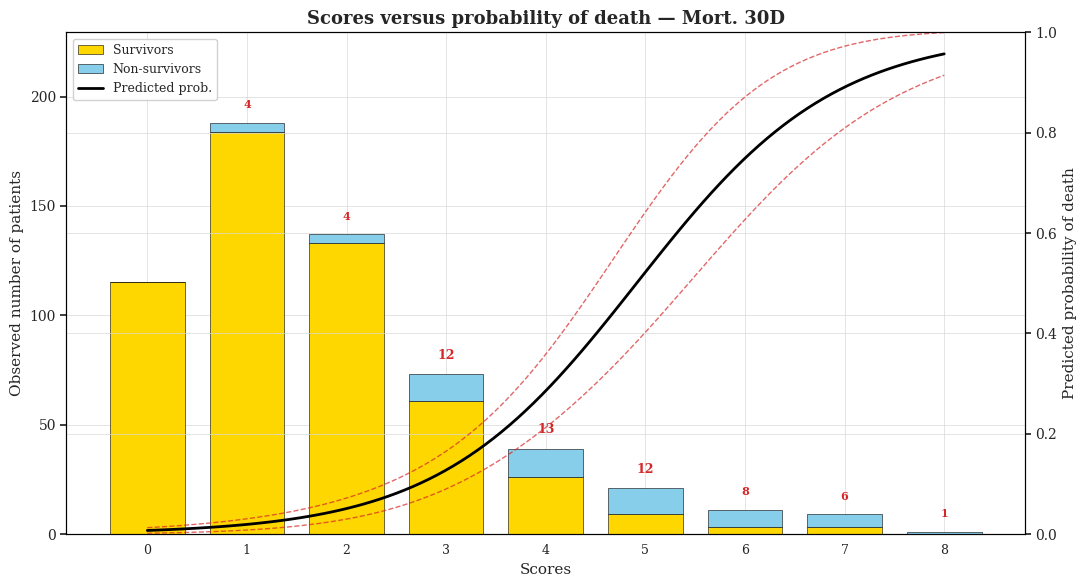

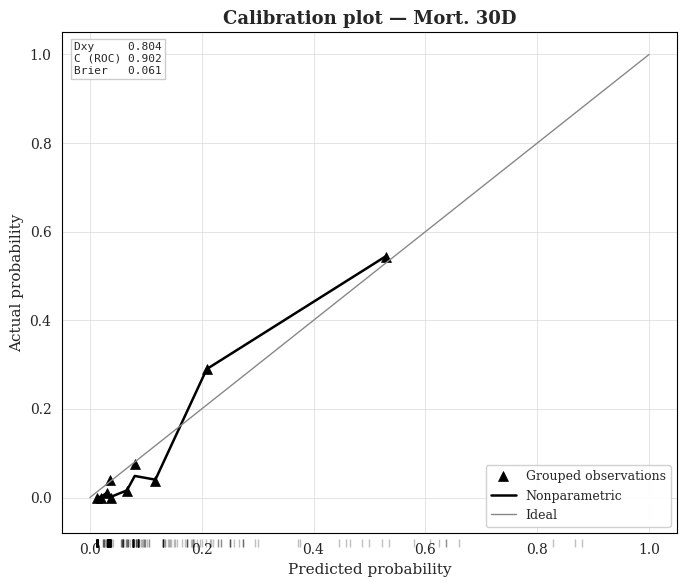

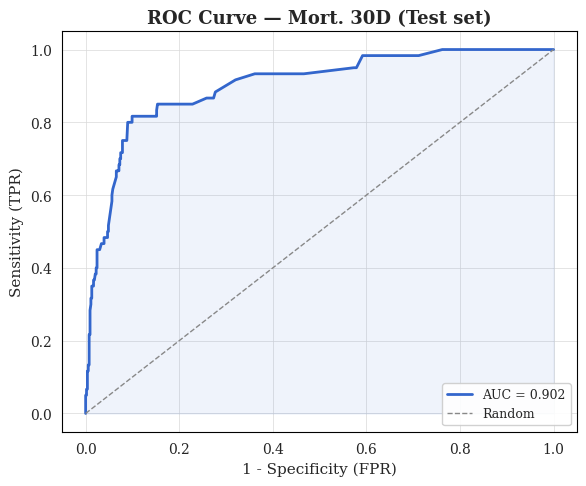

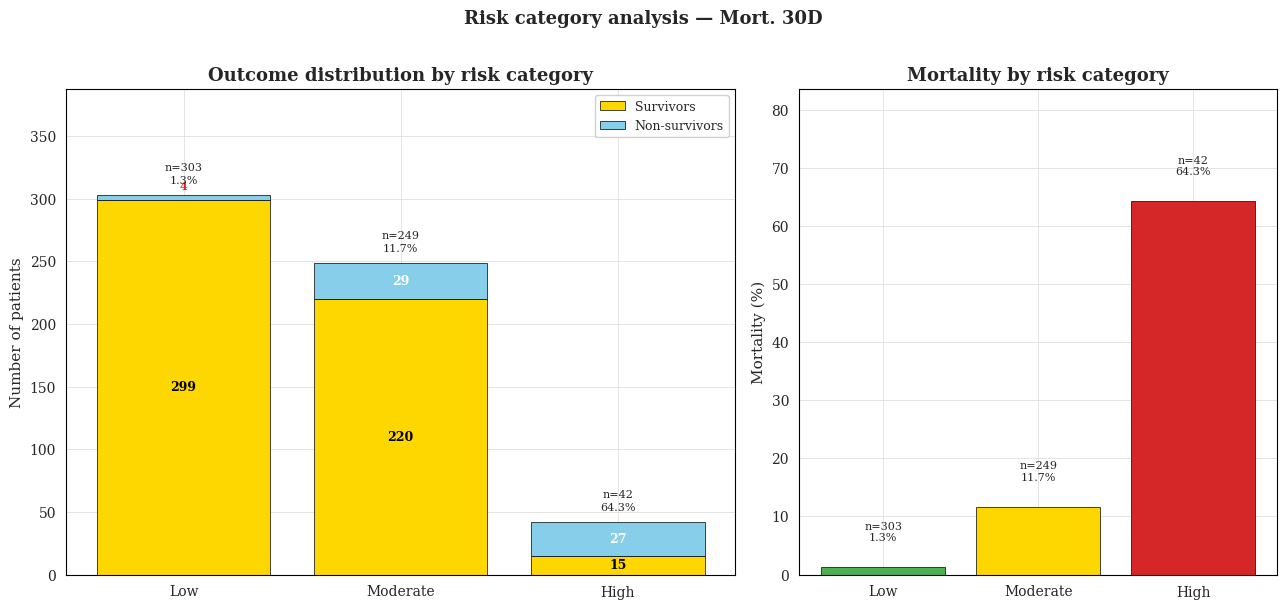

In [ ]:
"""
PURPOSE : Risk stratification + validation plots (Zhang et al. 2017 style).
          Each diagnostic plot is rendered as a SEPARATE figure.

Plots generated:
  Fig A — Scores vs probability of death (Zhang Fig 3)
  Fig B — Calibration plot (Zhang Fig 4)
  Fig C — ROC curve
  Fig D — Mortality by risk category (stacked absolute + mortality %)
"""

from sklearn.calibration import calibration_curve


def auto_risk_bins(scores, y, max_categories=4, min_bin_n=20):
    """Compute risk stratification bins automatically from score distribution."""
    s_min, s_max = int(scores.min()), int(scores.max())
    if s_max <= 3:
        return [s_min - 0.5, (s_min + s_max) / 2, s_max + 0.5], ("Low Risk", "High Risk")
    n_cats = min(max_categories, max(2, (s_max - s_min + 1) // 2))
    boundaries = list(np.linspace(s_min - 0.5, s_max + 0.5, n_cats + 1))
    boundaries = [round(b, 1) for b in boundaries]
    final_edges = [boundaries[0]]
    for edge in boundaries[1:]:
        mask = (scores >= final_edges[-1]) & (scores < edge)
        if mask.sum() < min_bin_n and len(final_edges) > 1:
            continue
        final_edges.append(edge)
    if final_edges[-1] < s_max + 0.5:
        final_edges[-1] = s_max + 0.5
    for _ in range(5):
        rates = []
        for j in range(len(final_edges) - 1):
            mask = (scores >= final_edges[j]) & (scores < final_edges[j + 1])
            y_bin = y[mask]
            rates.append(y_bin.mean() if len(y_bin) > 0 else 0)
        ok = True
        for j in range(len(rates) - 1):
            if rates[j] > rates[j + 1]:
                ok = False
                final_edges = final_edges[:j + 1] + final_edges[j + 2:]
                break
        if ok:
            break
    n_final = len(final_edges) - 1
    if n_final == 2:   labels = ("Low Risk", "High Risk")
    elif n_final == 3: labels = ("Low", "Moderate", "High")
    elif n_final == 4: labels = ("Very Low", "Low", "Moderate", "High")
    else:              labels = tuple(f"Risk {j+1}" for j in range(n_final))
    return final_edges, labels


bins_risk, RISK_LABELS = auto_risk_bins(test_scores, y_test, max_categories=4)
print(f"Automatic risk bins: {bins_risk}")
print(f"Labels: {RISK_LABELS}")

df_eval_test = pd.DataFrame({"score": test_scores.values, "outcome": y_test.values})
cat_dtype = pd.api.types.CategoricalDtype(categories=RISK_LABELS, ordered=True)
df_eval_test["category"] = pd.cut(
    df_eval_test["score"], bins=bins_risk, labels=RISK_LABELS,
    include_lowest=True, right=True).astype(cat_dtype)

risk_test = (df_eval_test.groupby("category", observed=False)
             .agg(**{"Score Min": ("score", "min"), "Score Max": ("score", "max"),
                     "N": ("outcome", "count"), "Events": ("outcome", "sum"),
                     "Mortality": ("outcome", "mean")})
             .assign(**{"Mortality %":  lambda d: (d["Mortality"] * 100).round(2),
                        "% Population": lambda d: (d["N"] / d["N"].sum() * 100).round(1)}))
risk_test["N"]         = risk_test["N"].astype(int)
risk_test["Events"]    = risk_test["Events"].astype(int)
risk_test["Survivors"] = (risk_test["N"] - risk_test["Events"]).astype(int)

display(Markdown("### Risk stratification table"))
display(risk_test)

mort_vals_arr = risk_test["Mortality"].dropna().values
gradiente_ok = all(mort_vals_arr[k] <= mort_vals_arr[k + 1]
                   for k in range(len(mort_vals_arr) - 1))
print(f"Monotonic mortality gradient: {'Yes' if gradiente_ok else 'No (check bins)'}")


# ══════════════════════════════════════════════════════════════════════════════
# Fig A — Scores vs probability of death  (Zhang Fig 3)
# ══════════════════════════════════════════════════════════════════════════════
fig_a, ax_a = plt.subplots(figsize=(11, 6))

score_min, score_max = int(test_scores.min()), int(test_scores.max())
score_vals = np.arange(score_min, score_max + 1)

counts_surv = np.array([((y_test.values == 0) & (test_scores.values == s)).sum()
                        for s in score_vals])
counts_dead = np.array([((y_test.values == 1) & (test_scores.values == s)).sum()
                        for s in score_vals])
totals_per_score = counts_surv + counts_dead

# Y-axis headroom: 20 % above the tallest bar so annotations fit
y_max_a = max(totals_per_score) if totals_per_score.max() > 0 else 1
ax_a.set_ylim(0, y_max_a * 1.22)
annot_offset_a = y_max_a * 0.022   # proportional vertical gap above bar top

x_bar = np.arange(len(score_vals))
bar_w = 0.75
ax_a.bar(x_bar, counts_surv, width=bar_w,
         color=TFG_COLORS["survivors"],     edgecolor="black", linewidth=0.4,
         label="Survivors")
ax_a.bar(x_bar, counts_dead, width=bar_w, bottom=counts_surv,
         color=TFG_COLORS["non_survivors"], edgecolor="black", linewidth=0.4,
         label="Non-survivors")

# Annotate number of deaths — only when n_dead > 0
y_range     = ax_a.get_ylim()[1] - ax_a.get_ylim()[0]
min_offset  = y_range * 0.025

for x_pos, count, bar_top in zip(range(len(counts_dead)), counts_dead, totals_per_score):
    if count > 0:
        y_text = bar_top + min_offset
        fs     = 8 if count < 10 else 9
        ax_a.text(x_pos, y_text, str(int(count)),
                ha="center", va="bottom",
                color=TFG_COLORS["ref_line"], fontsize=fs, fontweight="bold")

ax_a.set_xticks(x_bar)
ax_a.set_xticklabels([str(s) for s in score_vals], fontsize=9)
ax_a.set_xlabel("Scores")
ax_a.set_ylabel("Observed number of patients")

# Predicted probability overlay (secondary axis)
ax2_a = ax_a.twinx()
try:
    import statsmodels.api as sm_api
    score_with_const = sm_api.add_constant(test_scores.values.astype(float))
    glm_score = sm_api.GLM(y_test.values, score_with_const,
                            family=sm_api.families.Binomial()).fit()
    newx   = np.linspace(score_min, score_max, 100)
    newx_c = sm_api.add_constant(newx)
    prd    = glm_score.predict(newx_c)
    se     = glm_score.get_prediction(newx_c).se_mean
    ax2_a.plot(np.interp(newx, score_vals, x_bar), prd, "-",
               color=TFG_COLORS["pred_prob_line"], lw=2, label="Predicted prob.")
    ax2_a.plot(np.interp(newx, score_vals, x_bar), np.clip(prd + 1.96 * se, 0, 1),
               "--", color=TFG_COLORS["pred_prob_ci"], lw=1, alpha=0.7)
    ax2_a.plot(np.interp(newx, score_vals, x_bar), np.clip(prd - 1.96 * se, 0, 1),
               "--", color=TFG_COLORS["pred_prob_ci"], lw=1, alpha=0.7)
except Exception as _glm_err:
    print(f"\u26a0\ufe0f GLM overlay failed: {_glm_err}")

ax2_a.set_ylabel("Predicted probability of death")
ax2_a.set_ylim(0, 1.0)
ax2_a.set_yticks(np.arange(0, 1.05, 0.2))

lines1, labels1 = ax_a.get_legend_handles_labels()
lines2, labels2 = ax2_a.get_legend_handles_labels()
ax_a.legend(lines1 + lines2, labels1 + labels2,
            loc="upper left", fontsize=9, framealpha=0.9)
ax_a.set_title(f"Scores versus probability of death — {TARGET_COL}",
               fontweight="bold")
fig_a.tight_layout()
_save_fig(fig_a, f"fig_11A_scores_vs_prob_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig B — Calibration plot  (Zhang Fig 4)
# ══════════════════════════════════════════════════════════════════════════════
fig_b, ax_b = plt.subplots(figsize=(7, 6))

_n_distinct  = len(np.unique(np.round(p_test, 3)))
_n_cal_bins  = max(5, min(10, _n_distinct // 2))
frac_pos, mean_pred = calibration_curve(
    y_test.values, p_test, n_bins=_n_cal_bins, strategy="quantile")
ax_b.plot(mean_pred, frac_pos, "^",
          color=TFG_COLORS["calib_curve"], ms=7, lw=0,
          label="Grouped observations",
          markeredgecolor="black", markeredgewidth=0.5)

try:
    from statsmodels.nonparametric.smoothers_lowess import lowess as _lws
    sort_idx   = np.argsort(mean_pred)
    xsm, ysm   = mean_pred[sort_idx], frac_pos[sort_idx]
    frac_cal   = max(0.35, min(0.75, 4 / max(len(xsm), 1)))
    smoothed_cal = _lws(endog=ysm, exog=xsm, frac=frac_cal, it=1, return_sorted=True)
    ax_b.plot(np.clip(smoothed_cal[:, 0], 0, 1),
              np.clip(smoothed_cal[:, 1], 0, 1),
              "-", color=TFG_COLORS["calib_curve"], lw=1.8, label="Nonparametric")
except Exception as _e:
    ax_b.plot(mean_pred, frac_pos, "-", color=TFG_COLORS["calib_curve"],
              lw=1.5, label="Nonparametric")

ax_b.plot([0, 1], [0, 1], "-", color=TFG_COLORS["ideal_line"], lw=1, label="Ideal")
MAX_RUG   = 300
rug_data  = p_test
if len(rug_data) > MAX_RUG:
    rng      = np.random.default_rng(RANDOM_STATE)
    rug_data = rng.choice(rug_data, size=MAX_RUG, replace=False)

ax_b.plot(rug_data, np.full_like(rug_data, -0.02),
        "|", color="black", alpha=0.25, linewidth=0.6,
        transform=ax_b.get_xaxis_transform(), clip_on=False)

auc_val_cal = roc_auc_score(y_test.values, p_test)
brier_val   = brier_score_loss(y_test.values, p_test)
dxy_val     = 2 * auc_val_cal - 1
stats_text  = (f"Dxy     {dxy_val:.3f}\n"
               f"C (ROC) {auc_val_cal:.3f}\n"
               f"Brier   {brier_val:.3f}")
ax_b.text(0.02, 0.98, stats_text, transform=ax_b.transAxes, fontsize=8,
          verticalalignment="top", fontfamily="monospace",
          bbox=dict(boxstyle="square,pad=0.3", facecolor="white",
                    edgecolor="#cccccc"))
ax_b.set_xlabel("Predicted probability")
ax_b.set_ylabel("Actual probability")
ax_b.set_xlim(-0.05, 1.05)
ax_b.set_ylim(-0.08, 1.05)
ax_b.legend(loc="lower right", fontsize=9)
ax_b.set_title(f"Calibration plot — {TARGET_COL}", fontweight="bold")
fig_b.tight_layout()
_save_fig(fig_b, f"fig_11B_calibration_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig C — ROC curve
# ══════════════════════════════════════════════════════════════════════════════
fig_c, ax_c = plt.subplots(figsize=(6, 5))

fpr, tpr, _ = roc_curve(y_test.values, p_test)
auc_val     = roc_auc_score(y_test.values, p_test)
ax_c.plot(fpr, tpr, "-", color=TFG_COLORS["loess_curve"], lw=2,
          label=f"AUC = {auc_val:.3f}")
ax_c.plot([0, 1], [0, 1], "--", color=TFG_COLORS["ideal_line"], lw=1, label="Random")
ax_c.fill_between(fpr, tpr, alpha=0.08, color=TFG_COLORS["loess_curve"])
ax_c.set_xlabel("1 - Specificity (FPR)")
ax_c.set_ylabel("Sensitivity (TPR)")
ax_c.set_title(f"ROC Curve — {TARGET_COL} (Test set)", fontweight="bold")
ax_c.legend(loc="lower right")
fig_c.tight_layout()
_save_fig(fig_c, f"fig_11C_roc_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")


# ══════════════════════════════════════════════════════════════════════════════
# Fig D — Mortality by risk category (stacked + mortality %)
# ══════════════════════════════════════════════════════════════════════════════
cats      = risk_test.index.tolist()
n_surv_d  = risk_test["Survivors"].values.astype(int)
n_dead_d  = risk_test["Events"].values.astype(int)
n_total_d = risk_test["N"].values.astype(int)
mort_pct_d= risk_test["Mortality %"].values
x_pos     = np.arange(len(cats))
n_cat     = len(cats)

# ── Left panel: stacked absolute counts ──────────────────────────────────────
fig_d, axes_d = plt.subplots(1, 2, figsize=(13, 6),
                              gridspec_kw={"width_ratios": [1.4, 1]})
ax_d1 = axes_d[0]

# Y-axis: 25 % headroom above tallest bar for "n=total / xx.x%" annotation
y_max_d1 = int(n_total_d.max())
ax_d1.set_ylim(0, y_max_d1 * 1.28)
annot_gap_d1 = y_max_d1 * 0.025   # gap between bar top and annotation text

ax_d1.bar(x_pos, n_surv_d, color=TFG_COLORS["survivors"],
          edgecolor="black", linewidth=0.5, label="Survivors")
ax_d1.bar(x_pos, n_dead_d, bottom=n_surv_d,
          color=TFG_COLORS["non_survivors"], edgecolor="black",
          linewidth=0.5, label="Non-survivors")

# Minimum segment height (in data units) required to print text inside
_min_text_h = y_max_d1 * 0.04   # ~4 % of y-range

for xi, (ns, nd, nt, mp) in enumerate(
        zip(n_surv_d, n_dead_d, n_total_d, mort_pct_d)):

    # --- Survivor count inside the gold segment ---
    if ns >= _min_text_h:
        ax_d1.text(xi, ns / 2, str(int(ns)),
                   ha="center", va="center",
                   fontsize=9, color="black", fontweight="bold")
    else:
        # Segment too thin: show count just below bar top (outside)
        if ns > 0:
            ax_d1.text(xi, ns - annot_gap_d1 * 0.5, str(int(ns)),
                       ha="center", va="top", fontsize=8, color="black")

    # --- Death count inside the blue segment (or outside if too thin) ---
    if nd > 0:
        if nd >= _min_text_h:
            ax_d1.text(xi, ns + nd / 2, str(int(nd)),
                       ha="center", va="center",
                       fontsize=9, color="white", fontweight="bold")
        else:
            # Too thin: place count above the segment in red
            ax_d1.text(xi, ns + nd + annot_gap_d1 * 0.4, str(int(nd)),
                       ha="center", va="bottom", fontsize=8,
                       color=TFG_COLORS["ref_line"], fontweight="bold")

    # --- n=total / mortality % label above the complete bar ---
    ax_d1.text(xi, nt + annot_gap_d1, f"n={nt}\n{mp:.1f}%",
               ha="center", va="bottom", fontsize=8, linespacing=1.4)

ax_d1.set_xticks(x_pos)
ax_d1.set_xticklabels(cats, fontsize=10)
ax_d1.set_ylabel("Number of patients")
ax_d1.set_title("Outcome distribution by risk category", fontweight="bold")
ax_d1.legend(loc="upper right", fontsize=9)

# ── Right panel: mortality % (colour gradient low→high) ──────────────────────
ax_d2 = axes_d[1]

if n_cat <= 2:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["ref_line"]]
elif n_cat == 3:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["survivors"],
                  TFG_COLORS["ref_line"]]
else:
    colors_bar = [TFG_COLORS["alive_leaf"], TFG_COLORS["survivors"],
                  "#FF7F00", TFG_COLORS["ref_line"]]

# Y-axis headroom: 30 % above tallest bar
max_mort_pct = float(mort_pct_d.max()) if len(mort_pct_d) > 0 else 1.0
ax_d2.set_ylim(0, max(max_mort_pct * 1.30, 5.0))   # at least 5 % so label fits
annot_gap_d2 = max_mort_pct * 0.025

bars = ax_d2.bar(x_pos, mort_pct_d,
                 color=colors_bar[:n_cat],
                 edgecolor="black", linewidth=0.5)
ax_d2.set_xticks(x_pos)
ax_d2.set_xticklabels(cats, fontsize=10)
ax_d2.set_ylabel("Mortality (%)")
ax_d2.set_title("Mortality by risk category", fontweight="bold")

y_range = ax_d2.get_ylim()[1] - ax_d2.get_ylim()[0]
offset  = y_range * 0.03
min_gap = y_range * 0.05

for bar, label in zip(bars, [f"n={nt}\n{mp:.1f}%" for nt, mp in zip(n_total_d, mort_pct_d)]):
    bar_top = bar.get_height()
    y_pos   = max(bar_top + offset, bar_top + min_gap)
    ax_d2.text(bar.get_x() + bar.get_width() / 2, y_pos,
            label, ha="center", va="bottom", fontsize=8)

fig_d.suptitle(f"Risk category analysis — {TARGET_COL}",
               fontsize=13, fontweight="bold", y=1.01)
fig_d.tight_layout()
_save_fig(fig_d, f"fig_11D_risk_categories_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")


## **12. Clinical score card**

The following table summarises the integer point assignment for each variable level
following the β-rounding method (Zhang et al. 2017).

To use at the bedside: sum the points for each variable and consult the risk category
table to interpret the total score.

`VAR_DISPLAY` maps internal column names to English/Spanish labels; it includes
`ST_cat` for cases where ST is part of the active feature set.


In [ ]:
VAR_DISPLAY = {
    "Edad_cat":     ("Age",                "Edad",               "years"),
    "GCS_cat":      ("Glasgow Coma Scale", "Escala Glasgow",     "3–15"),
    "Lactato_cat":  ("Lactate",            "Lactato",            "mmol/L"),
    "SpO2_cat":     ("O2 Saturation",      "Saturación O2",      "%"),
    "O2_cat":       ("Supplemental O2",    "O2 Suplementario",   "0/1"),
    "TT_cat":       ("Temperature",        "Temperatura",        "°C"),
    "FR_cat":       ("Respiratory Rate",   "Frec. Respiratoria", "rpm"),
    "Glucemia_cat": ("Blood Glucose",      "Glucemia",           "mg/dL"),
    "TAM_cat":      ("Mean Arterial Pressure", "TAM",            "mmHg"),
    "Ritmo_cat":    ("Heart Rhythm",           "Ritmo cardiaco", "grupo clínico"),
    "ST_cat":       ("ST Segment",              "Segmento ST",        "grupo clínico"),
    "Resrv._cat":   ("Reservoir Mask O2",      "Reservorio",     "0/1"),
    "Gafas_cat":    ("Nasal Cannula O2",       "Gafas",          "0/1"),
    "VNI_cat":      ("Non-Invasive Ventilation","VNI",           "0/1"),
    "VAD_cat":      ("Vasoactive Drugs",       "VAD",            "0/1"),
    "Venturi_cat":  ("Venturi Mask O2",        "Venturi",        "0/1"),
}

print("═" * 80)
print(" " * 8 + f"EMERGENCY DEPARTMENT {TARGET_COL.upper()} MORTALITY RISK SCORE")
print(" " * 20 + "(Zhang et al., 2017 — β-rounding method)")
print("═" * 80)

for var in score_cat_cols:
    if var not in VAR_DISPLAY:
        continue
    name_en, name_es, unit = VAR_DISPLAY[var]
    var_data = points_df[points_df["variable"] == var].sort_values("points")
    print(f"\n{'─' * 80}")
    print(f"  {name_en} / {name_es}  [{unit}]")
    print(f"  {'─' * 50}")
    print(f"  {'Category':<35} {'β':>8} {'Points':>8} {'Ref':>6}")
    print(f"  {'─' * 59}")
    for _, row in var_data.iterrows():
        ref_mark = "✓" if row["is_reference"] else ""
        print(f"  {str(row['level']):<35} {row['beta']:>8.3f} "
              f"{int(row['points']):>8} {ref_mark:>6}")

print(f"\n{'═' * 80}")
print("RISK CATEGORY INTERPRETATION")
print(f"{'═' * 80}")
print(f"  {'Category':<12} {'Score Range':<15} {'Mortality %':>12} {'% Patients':>12}")
print(f"  {'─' * 55}")
for cat, row in risk_test.iterrows():
    sc_min = int(row['Score Min']) if pd.notna(row['Score Min']) else '?'
    sc_max = int(row['Score Max']) if pd.notna(row['Score Max']) else '?'
    print(f"  {str(cat):<12} {f'{sc_min}–{sc_max}':<15} "
          f"{row['Mortality %']:>11.1f}% {row['% Population']:>11.1f}%")

print(f"\n  Maximum theoretical score: {MAX_SCORE} points")
print(f"  AUC-ROC (test): {roc_auc_score(y_test, test_scores):.3f}  |  "
      f"Brier Score: {brier_score_loss(y_test, p_test):.3f}")
print("═" * 80)

════════════════════════════════════════════════════════════════════════════════
        EMERGENCY DEPARTMENT MORT. 30D MORTALITY RISK SCORE
                    (Zhang et al., 2017 — β-rounding method)
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
  Age / Edad  [years]
  ──────────────────────────────────────────────────
  Category                                   β   Points    Ref
  ───────────────────────────────────────────────────────────
  (-inf, 58]                             0.000        0      ✓
  (58, 72]                               0.961        1       
  (72, 85]                               1.083        1       
  (85, +inf]                             1.891        2       

────────────────────────────────────────────────────────────────────────────────
  Glasgow Coma Scale / Escala Glasgow  [3–15]
  ──────────────────────────────────────────────────
  

## **13. Confusion matrix**

The confusion matrix is computed at the threshold that maximises the **Youden index** (Sensitivity + Specificity − 1), a standard approach for selecting an operating point in clinical risk models.

Optimal threshold (Youden): 3 points
Sensitivity: 0.867 | Specificity: 0.809


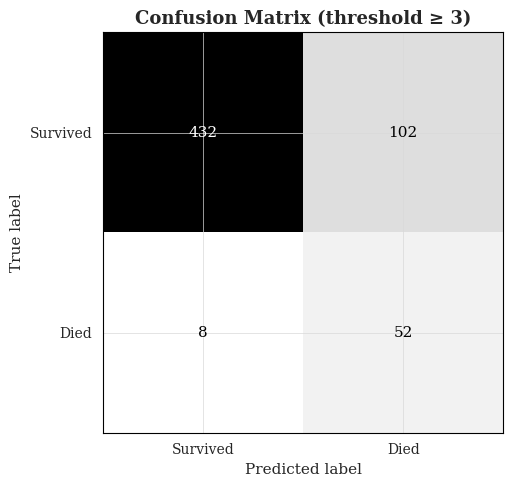


Classification Report:
              precision    recall  f1-score   support

    Survived       0.98      0.81      0.89       534
        Died       0.34      0.87      0.49        60

    accuracy                           0.81       594
   macro avg       0.66      0.84      0.69       594
weighted avg       0.92      0.81      0.85       594



In [ ]:
# Optimal threshold by Youden index on test scores
fpr_s, tpr_s, thr_s = roc_curve(y_test.values, test_scores.values)
youden   = tpr_s - fpr_s
best_idx = np.argmax(youden)
best_thr = thr_s[best_idx]

y_pred_opt = (test_scores.values >= best_thr).astype(int)

print(f"Optimal threshold (Youden): {best_thr:.0f} points")
print(f"Sensitivity: {tpr_s[best_idx]:.3f} | Specificity: {1 - fpr_s[best_idx]:.3f}")

cm = confusion_matrix(y_test.values, y_pred_opt)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Survived", "Died"])
disp.plot(ax=ax, colorbar=False, cmap="Greys")
ax.set_title(f"Confusion Matrix (threshold ≥ {best_thr:.0f})", fontweight="bold")
plt.tight_layout()
_save_fig(fig, f"fig_13_confusion_matrix_{TARGET_COL.replace(" ", "_").replace(".", "")}.png")

print("\nClassification Report:")
print(classification_report(y_test.values, y_pred_opt,
                             target_names=["Survived", "Died"]))

## **14. Conclusions**

### Risk scoring system performance

The risk scoring system was developed following **Zhang et al. (2017)**, converting
ridge logistic regression β coefficients to integer points via β-rounding.
Variables were selected through VIF + AIC/BIC backward stepwise regression;
the active feature set is defined in `FEATURES_PER_OUTCOME`.

### Key findings

**Variable contributions:**
- **GCS** and **Lactate** are consistently the strongest predictors, reflecting
  the clinical relevance of neurological status and metabolic acidosis in short-term mortality.
- **Age** and **SpO2** provide additive discriminative value across all outcomes.
- **O2**, **Temperature (TT)**, and **Respiratory Rate (FR)** show clinically plausible contributions.
- **Ritmo** and **ST** are included in the VIF/AIC design matrix as categorical variables. Given their rarity in prehospital emergency datasets, they are not expected to appear in the final feature set, but the pipeline supports them fully.

**Score design:**
- Integer scale facilitates bedside calculation without electronic tools.
- Automatic risk strata (Very Low → High) provide clear clinical action thresholds.

---

> This scoring system is the reference for evaluating synthetic data
> utility. The next phase trains the same pipeline on synthetic data and tests on real data (*Train on Synthetic, Test on Real*), using AUC-ROC comparison as the primary utility metric.


### **Final summary**

The box below consolidates the key results of this notebook for the active target
outcome (`TARGET_COL`). It is printed last to ensure all upstream computations
(VIF, AIC/BIC, Ridge CV, score computation, risk stratification) have already executed.

**Metrics reported:**
- `AUC-ROC (Score)` — discrimination of the **integer score** on the test set.
- `Brier Score` — overall calibration + discrimination of the Ridge probability estimates.
- `H-L p-value` — Hosmer-Lemeshow goodness-of-fit; p > 0.05 indicates adequate calibration.
- `Monotonic gradient` — confirms that higher score categories have strictly higher mortality.
- Risk category table — score ranges, mortality %, and patient counts per stratum.

> Re-run with `TARGET_COL = "Mort. 2D"` or `"Mort. 30D"` to obtain results for the
> other two mortality endpoints.


In [ ]:
auc_f   = roc_auc_score(y_test, test_scores)
brier_f = brier_score_loss(y_test, p_test)

def _row(label: str, value: str, width: int = 78) -> str:
    """Format a fixed-width box row: ║  label : value  ║"""
    content = f"  {label:<18}: {value}"
    return "║" + content + " " * (width - len(content)) + "║"

print("\n")
print("╔" + "═" * 78 + "╗")
print("║" + f" RISK SCORING SYSTEM — FINAL SUMMARY ({TARGET_COL}) ".center(78) + "║")
print("╠" + "═" * 78 + "╣")
print(_row("Method",          "β-rounding (round(β) per level)"))
print(_row("Variables",       f"{len(score_cat_cols)} categorical predictors"))
print(_row("Max Score",       f"{MAX_SCORE} points"))
print(_row("Risk categories", f"{len(RISK_LABELS)}"))
print("╠" + "═" * 78 + "╣")
print(_row("AUC-ROC (Score)", f"{auc_f:.4f}"))
print(_row("Brier Score",     f"{brier_f:.4f}"))
hl_p = metrics_test.get("H-L p-value", float("nan"))
print(_row("H-L p-value",     f"{hl_p:.4f}"))
gradiente_ok = locals().get("gradiente_ok", None)
grad_str = "Yes ✅" if gradiente_ok is True else ("No ⚠️" if gradiente_ok is False else "N/A")
print(_row("Monotonic grad.", grad_str))
print("╠" + "═" * 78 + "╣")
print("║  RISK CATEGORY TABLE" + " " * 57 + "║")
print("╟" + "─" * 78 + "╢")
header = f"  {'Category':<14} {'Score range':<13} {'Mortality %':>12} {'N':>8} {'% Cohort':>10}"
print("║" + header + " " * (78 - len(header)) + "║")
print("╟" + "─" * 78 + "╢")
for cat, row in risk_test.iterrows():
    sc_min    = int(row["Score Min"]) if pd.notna(row["Score Min"]) else "?"
    sc_max    = int(row["Score Max"]) if pd.notna(row["Score Max"]) else "?"
    sc_range  = f"{sc_min}–{sc_max}"
    n_pat     = int(row["N"])
    line = (f"  {str(cat):<14} {sc_range:<13} {row['Mortality %']:>11.1f}%"
            f" {n_pat:>8} {row['% Population']:>9.1f}%")
    print("║" + line + " " * (78 - len(line)) + "║")
print("╚" + "═" * 78 + "╝")



╔══════════════════════════════════════════════════════════════════════════════╗
║               RISK SCORING SYSTEM — FINAL SUMMARY (Mort. 30D)                ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Method            : β-rounding (round(β) per level)                         ║
║  Variables         : 6 categorical predictors                                ║
║  Max Score         : 9 points                                                ║
║  Risk categories   : 3                                                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  AUC-ROC (Score)   : 0.8947                                                  ║
║  Brier Score       : 0.0606                                                  ║
║  H-L p-value       : 0.0951                                                  ║
║  Monotonic grad.   : Yes ✅                                                   ║
╠═════════════════════════

## **15. Export**

All figures have been saved to disk at the point of creation (5–13).
This cell saves the key **tables** as CSV files to the same output directory
(`OUTPUT_DIR = .../PREPROCESSING/NB4_RSS`).

| File | Content |
|------|---------|
| `tbl_03_vif_final_*.csv` | Final VIF table after iterative removal |
| `tbl_04_aic_history_*.csv` | AIC backward stepwise step-by-step history |
| `tbl_05_coef_table_*.csv` | β, OR, p-values for the AIC-selected model |
| `tbl_10_scoring_table_*.csv` | Integer points per (variable, level) |
| `tbl_11_validation_metrics_*.csv` | AUC-ROC, Brier, H-L per split |
| `tbl_11_clinical_metrics_*.csv` | Sensitivity / specificity per threshold |
| `tbl_11_risk_stratification_*.csv` | Risk category table |

> Filenames include the active `TARGET_COL` suffix for traceability.
> Run for each outcome (`Mort. 2D`, `Mort. 7D`, `Mort. 30D`) to produce the full set.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §15  EXPORT — Tables to OUTPUT_DIR
# ══════════════════════════════════════════════════════════════════════════════
"""
PURPOSE : Save key result tables from NB4 as CSV files to OUTPUT_DIR.
          Figures are saved at the point of creation in §§5–13.

Input   : All variables are produced by the cells above (VIF, AIC, Ridge CV, etc.)
Output  : CSV files in OUTPUT_DIR keyed by section and TARGET_COL suffix.
"""

import os
import pandas as pd

os.makedirs(OUTPUT_DIR, exist_ok=True)
_suffix = TARGET_COL.replace(" ", "_").replace(".", "")
_saved = []

def _export_df(df_in, name):
    path = os.path.join(OUTPUT_DIR, f"{name}_{_suffix}.csv")
    df_in.to_csv(path, index=False)
    _saved.append(path)
    print(f"  ✓ {name}_{_suffix}.csv")

# §3 VIF final table
try:
    _export_df(vif_final, "tbl_03_vif_final")
except NameError:
    print("  — vif_final not found (§3 may not have run)")

# §4 AIC stepwise history
try:
    _export_df(hist_aic, "tbl_04_aic_history")
except NameError:
    print("  — hist_aic not found (§4 may not have run)")

# §5 Coefficient table (AIC model)
try:
    _export_df(coef_table_sm_full(sm_aic, drop_const=True), "tbl_05_coef_table")
except NameError:
    print("  — sm_aic not found (§4 may not have run)")

# §10 Scoring table
try:
    _export_df(points_df, "tbl_10_scoring_table")
except NameError:
    print("  — points_df not found (§10c may not have run)")

# §11 Validation metrics (train + test combined)
try:
    _rows = []
    for split_name, m_dict in [("train", metrics_train), ("test", metrics_test)]:
        for k, v in m_dict.items():
            _rows.append({"split": split_name, "metric": k, "value": v})
    _export_df(pd.DataFrame(_rows), "tbl_11_validation_metrics")
except NameError:
    print("  — metrics_train / metrics_test not found (§11 may not have run)")

# §11 Clinical metrics at multiple thresholds
try:
    _export_df(clinical_df, "tbl_11_clinical_metrics")
except NameError:
    print("  — clinical_df not found (§11 may not have run)")

# §11 Risk stratification table
try:
    _export_df(risk_test.reset_index(), "tbl_11_risk_stratification")
except NameError:
    print("  — risk_test not found (§11 may not have run)")

print(f"\n✅ Export complete — {len(_saved)} table(s) saved to:\n   {OUTPUT_DIR}")


  ✓ tbl_03_vif_final_Mort_30D.csv
  ✓ tbl_04_aic_history_Mort_30D.csv
  ✓ tbl_05_coef_table_Mort_30D.csv
  ✓ tbl_10_scoring_table_Mort_30D.csv
  ✓ tbl_11_validation_metrics_Mort_30D.csv
  ✓ tbl_11_clinical_metrics_Mort_30D.csv
  ✓ tbl_11_risk_stratification_Mort_30D.csv

✅ Export complete — 7 table(s) saved to:
   /content/drive/MyDrive/Colab Notebooks/TFG/PREPROCESSING/NB4_RSS
